# Notebook 13 - the uncalibrated baseline run

**Purpose.** Notebook 12 produced a validated input bundle. `src/mgb_hydrology.py` is the tested
engine (59/59 assertions, reproduces `notebooks/03_hydrology.ipynb` cell 7 to 1.8e-15 mm/day). This
notebook is the first time the two meet on the real basin.

**What this notebook is NOT.** It is not a calibration. Nothing here is fitted to observed
discharge - the parameter set is fixed *before* the first comparison with a gauge, and section 5.5
audits the code path to prove no observed flow can reach the model. The deliverable is a
**defensible baseline**: a run whose every number is traceable to either measured data or a written
prior, whose mass balance closes to machine precision, and whose errors are decomposed far enough
that the calibration that follows knows what it is being asked to fix.

**The four questions this notebook has to answer.**

1. Does the model conserve mass on 8,672 minibacias over 3,652 scored days? (Section 4 - if this
   nothing after it means anything.)
2. Is the initial state forgotten? (Section 3 - a warm-up is only long enough if the answer
   stops depending on where it started.)
3. How wrong is the uncalibrated baseline, and *in which component*? (Section 5 - correlation,
   variability or bias. Calibration attacks these with different knobs.)
4. Is the error spatially structured? (Section 6 - a spatially random error is a parameter problem;
   a spatially organised one is usually a forcing or a routing problem, and calibration cannot
   fix it.)

**Working rules applied throughout** (the user's, and not decoration):

1. Every parameter, method and threshold states its reason **and** an alternative that was rejected.
2. Every headline number is recomputed a **second, independent way**. Where the two disagree, the
   disagreement is reported, not resolved by preference.
3. New helper code passes a **synthetic smoke test with an analytically known answer** (section 0.3)
   before it touches basin data.
4. No number appears here that this notebook did not compute.
5. Where a result looks good it is attacked. Section 5.5 exists because one gauge scores KGE ~ 0.77
   in an uncalibrated run, and a plausibility band would have waved that through.

## 0.1 - Prerequisites

| Prerequisite | What it provides | Checked below |
|---|---|---|
| `src/mgb_hydrology.py` | the water-balance engine: `build_topology`, `MgbParams`, `MgbState`, `simulate` | version + import |
| `data/processed/model_inputs_v2/topology.npz` | routing graph, own/upstream area, `reach_km`, centroids | shapes vs manifest |
| `data/processed/model_inputs_v2/parameters.npz` | `Wm_mm`, 24 URH fractions, flags | shapes vs manifest |
| `data/processed/model_inputs_v2/forcing.npz` | P and PET, 2008-01-01..2018-12-31 | no NaN, no negatives, **date axis vs an independently declared period** |
| `data/processed/model_inputs_v2/discharge.npz` | observed Q, `q_valid`, calibration-set flags | used only from s.5 |
| `data/processed/forcing_minibacia_precip_v2.csv` | the human-auditable rainfall table | re-parsed in s.4.3 as a second reader |
| `data/processed/minibacias.tif` | label raster, for maps | used only for figures |

If any of these is missing this notebook stops - it does not improvise a substitute.

**This is the v2 bundle, and the period changed.** The v1 bundle ran 2009-01-01..2017-12-31 (3,287
d) and kept 2008 rainfall *outside* it because no 2008 PET existed - only 108 of the 132 ERA5-Land
mosaics had been built. All 132 now exist (one, `2008_M06`, was internally corrupt at a plausible
43.69 MB and was rebuilt), so the v2 bundle spans **2008-01-01..2018-12-31, 4,018 days**, and
`manifest.json` records `warmup_available_days = 0`: nothing precedes the period, so the spin-up
must be taken from *inside* it. **2008 is the warm-up year and 2009-2018 is scored.** That decision
is the manifest's, not this notebook's, and it is not re-argued here.

**The check that is not optional.** `pd.read_csv` on these 4,018 x 8,673 / 180 MB tables silently
returned 1,309 and then 3,630 rows on separate calls from a provably complete file, with no
exception. The cut is a contiguous *prefix*, so length, monotonicity, duplicate and calendar-hole
tests all pass on the truncated data. The only test that catches it is one against a period declared
**independently of the file**, which is why `assert DATES.equals(WANT)` appears in the cell below and
is never loosened to make something else pass.

In [1]:
import json, pathlib, sys, time, hashlib, warnings
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm, ListedColormap
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': False, 'font.size': 9})

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b / 'src' / 'mgb_hydrology.py').exists() and (b / 'data' / 'processed').exists():
        REPO = b
        break
if REPO is None:
    raise SystemExit('cannot locate the repository root')
PROC = REPO / 'data' / 'processed'
MI = PROC / 'model_inputs_v2'
sys.path.insert(0, str(REPO / 'src'))

need = ['topology.npz', 'parameters.npz', 'forcing.npz', 'discharge.npz', 'manifest.json']
missing = [f for f in need if not (MI / f).exists()]
missing += [str(p) for p in [REPO / 'src' / 'mgb_hydrology.py',
                             PROC / 'forcing_minibacia_precip_v2.csv',
                             PROC / 'minibacias.tif'] if not p.exists()]
if missing:
    raise SystemExit(f'PREREQUISITES MISSING, stopping rather than improvising: {missing}')

import mgb_hydrology as mgb
eng_src = (REPO / 'src' / 'mgb_hydrology.py').read_bytes()
print(f'repo            {REPO}')
print(f'engine          src/mgb_hydrology.py  {len(eng_src)/1024:.1f} kB  '
      f'sha256 {hashlib.sha256(eng_src).hexdigest()[:16]}')
print(f'engine exports  {len(mgb.__all__)} names, MM_KM2_PER_DAY_TO_M3S = '
      f'{mgb.MM_KM2_PER_DAY_TO_M3S:.9f}')
print(f'inputs          {MI}  ({sum(f.stat().st_size for f in MI.iterdir())/1e6:.1f} MB)')

TOP = dict(np.load(MI / 'topology.npz'))
PAR = dict(np.load(MI / 'parameters.npz', allow_pickle=True))
FRC = dict(np.load(MI / 'forcing.npz'))
DIS = dict(np.load(MI / 'discharge.npz', allow_pickle=True))
MAN = json.loads((MI / 'manifest.json').read_text())

# independent shape check against the manifest: a silent re-generation of the bundle with
# a different minibacia count would otherwise break only much later, inside a broadcast.
bad = []
for fn, arrs in ((f, MAN['files'][f]['arrays']) for f in
                 ('topology.npz', 'parameters.npz', 'forcing.npz', 'discharge.npz')):
    got = {'topology.npz': TOP, 'parameters.npz': PAR, 'forcing.npz': FRC,
           'discharge.npz': DIS}[fn]
    for k, spec in arrs.items():
        if k not in got:
            bad.append(f'{fn}:{k} absent')
        elif list(got[k].shape) != list(spec['shape']):
            bad.append(f'{fn}:{k} shape {got[k].shape} != manifest {spec["shape"]}')
if bad:
    raise SystemExit(f'bundle does not match its own manifest: {bad}')
print(f'manifest check  every array in 4 npz matches its declared shape '
      f'({sum(len(MAN["files"][f]["arrays"]) for f in MAN["files"] if f.endswith("npz"))} arrays)')

# TRAP, and it cost a run. FRC['dates'] is datetime64[D]; pandas 2.x keeps that resolution,
# while pd.date_range produces datetime64[ns]. DatetimeIndex.equals compares resolution too,
# so the two are UNEQUAL while printing identically ("2008-01-01..2018-12-31, 4018 d" on both
# sides of the failed assertion). Cast the unit explicitly; do not weaken the comparison.
DATES_ALL = pd.DatetimeIndex(np.asarray(FRC['dates'], dtype='datetime64[ns]'))
MB_IDS = TOP['minibacia_id']
NDAYS_ALL, NMB = FRC['precip_mm'].shape

# --- the assertion that catches a silent truncation -----------------------------------
# WANT is declared here, from two literal dates, NOT read from the file. A reader that
# returns a contiguous prefix passes every self-consistency test there is; only a
# comparison with an independently declared period fails. Do not loosen this.
WANT = pd.date_range('2008-01-01', '2018-12-31', freq='D')
assert len(DATES_ALL) == NDAYS_ALL and MB_IDS.size == NMB
assert DATES_ALL.equals(WANT), (
    f'bundle date axis is {DATES_ALL[0].date()}..{DATES_ALL[-1].date()} ({len(DATES_ALL)} d), '
    f'declared period is {WANT[0].date()}..{WANT[-1].date()} ({len(WANT)} d)')
print(f'bundle period   {DATES_ALL[0].date()} .. {DATES_ALL[-1].date()}  {NDAYS_ALL} days, '
      f'{NMB} minibacias   (matches the independently declared period)')
print(f'manifest says   warmup_available_days = {MAN["model_period"]["warmup_available_days"]}, '
      f'days = {MAN["model_period"]["days"]}')
assert MAN['model_period']['days'] == NDAYS_ALL

# --- the split the manifest prescribes: 2008 warms up, 2009-2018 is scored -------------
WU_MASK = DATES_ALL.year == 2008
SC_MASK = ~WU_MASK
D_WU = DATES_ALL[WU_MASK]
DATES = DATES_ALL[SC_MASK]
NDAYS = int(SC_MASK.sum())
NWU = int(WU_MASK.sum())
assert NWU == 366 and NDAYS == 3652 and NWU + NDAYS == NDAYS_ALL
print(f'warm-up         {D_WU[0].date()} .. {D_WU[-1].date()}  {NWU} days   (discarded)')
print(f'scored period   {DATES[0].date()} .. {DATES[-1].date()}  {NDAYS} days')

repo            C:\dev\magdalena-mgb-sed
engine          src/mgb_hydrology.py  44.0 kB  sha256 cdea026afe796f6d
engine exports  16 names, MM_KM2_PER_DAY_TO_M3S = 0.011574074
inputs          C:\dev\magdalena-mgb-sed\data\processed\model_inputs_v2  (108.8 MB)


manifest check  every array in 4 npz matches its declared shape (48 arrays)
bundle period   2008-01-01 .. 2018-12-31  4018 days, 8672 minibacias   (matches the independently declared period)
manifest says   warmup_available_days = 0, days = 4018
warm-up         2008-01-01 .. 2008-12-31  366 days   (discarded)
scored period   2009-01-01 .. 2018-12-31  3652 days


## 0.2 - The model, restated

This is the formulation derived in `notebooks/03_hydrology.ipynb` sections 1-5, with the canopy
store that notebook names ("*P - precipitation reaching the soil, after canopy interception*") but
never codes. It is **not** HBV, GR4J or Sacramento. Two nested resolutions, exactly as nb03 s.5
prescribes: the soil column is solved per **URH** (soil family x land cover, 24 types), the three
linear reservoirs and the channel live at the **minibacia**.

**1. Canopy interception** (MGB-IPH; a bucket of capacity $S_{i,max} = \alpha_{int}\,\mathrm{LAI}$
that evaporates at the *potential* rate):

$$S_c \leftarrow S_c + P,\qquad
P_{thr} = \max(S_c - S_{i,max},\,0),\qquad S_c \leftarrow S_c - P_{thr}$$
$$E_{can} = \min(PET,\,S_c),\qquad S_c \leftarrow S_c - E_{can},\qquad PET_{soil} = PET - E_{can}$$

With $\mathrm{LAI}=0$ the store is inert and $P_{thr}\equiv P$, so the engine degrades *exactly* to
notebook 03. Section 4.5 measures what switching it on costs.

**2. Saturation-excess runoff on a variable contributing area** (nb03 s.2, verbatim):

$$A_{sat} = 1-\left(1-\frac{W}{W_m}\right)^{b},\qquad D_{sup} = P_{thr}\,A_{sat},\qquad
W \leftarrow W + P_{thr} - D_{sup}$$

then nb03's second, "bucket-full" term: if $W>W_m$, $\;D_{sup} \mathrel{+}= W-W_m$ and $W = W_m$.

**3. Evapotranspiration, limited by demand *and* supply** (nb03 s.1):

$$ET = \min\!\left(k_c\,PET_{soil}\,\frac{W}{W_m},\; W\right),\qquad W \leftarrow W - ET$$

**4. Percolation out of the soil column** (`percolation='linear'`, nb03 s.4 cell 7):

$$\text{drain} = a_{dr}\,W,\qquad D_{int} = f_{int}\,\text{drain},\qquad
D_{bas} = (1-f_{int})\,\text{drain},\qquad W \leftarrow W - \text{drain}$$

**5. Three linear reservoirs at the minibacia** (nb03 s.3, which writes the recession as
$Q(t) = Q_0 e^{-t/K}$). The engine's default `reservoir='exact'` uses the analytic one-day solution
of that very ODE, rather than nb03 cell 7's Euler form $Q=S/K$:

$$S \leftarrow S + \textstyle\sum_u f_u D_u,\qquad Q = S\left(1-e^{-\Delta t/K}\right),\qquad
S \leftarrow S - Q$$

for $K \in \{K_{sup}, K_{int}, K_{bas}\}$. The inflow is the **area-weighted** sum over the URHs of
the minibacia, so the reservoir depths are referenced to the minibacia's *full* area while $W$ and
$S_c$ are referenced to the URH's *own* area - a distinction the engine's `storage_volume()`
docstring flags as easy to get wrong and invisible on this project's data (its URH fractions sum to
exactly 1).

**6. Channel routing** - one linear reservoir per reach (Muskingum with $X=0$), solved with a
*within-day* topological sweep so water can cross many reaches in one day:

$$S_i \leftarrow S_i + \text{local}_i + \sum_{j \to i} Q_j,\qquad
Q_i = S_i\left(1-e^{-\Delta t/\tau_i}\right),\qquad S_i \leftarrow S_i - Q_i$$

The engine's docstring records why Muskingum-Cunge, integer-day translation, instantaneous
accumulation and a local-inertial scheme were each rejected. The consequence that matters for
section 6: **backwater and floodplain storage in the Mompos depression / La Mojana wetlands are not
represented**, so gauges there carry timing error no calibration of this engine can remove.

**Mass balance.** Over any window, in $\mathrm{mm\,km^2}$:

$$\underbrace{\sum P}_{\text{gross rainfall}} + \underbrace{\sum \text{clip}}_{\text{guard, must be }0}
\;-\; \sum ET \;-\; \sum Q_{outlet} \;-\; \Delta V = 0$$

with $V = \sum_c (S_c + W)\,A_c + \sum_i (S_{sup}+S_{int}+S_{bas})_i A_i + \sum_i S_{ch,i}$.
Section 4.2 requires this to close to $\le 10^{-6}$ relative.

## 0.3 - Smoke tests on synthetic cases, before any basin data

The engine is already tested (`src/test_mgb_hydrology.py`, 59/59). What is **new in this notebook**
is one helper, so that is what gets tested here:

* `kge_parts` - KGE and its decomposition, NSE, PBIAS. Every assertion below has a closed-form
  answer, so a sign slip or a `ddof` slip cannot hide.

**What used to be here and is now retired.** The v1 run needed a `pet_climatology` helper, because
the v1 bundle had 2008 rainfall but no 2008 PET, so the warm-up had to invent a PET stand-in from a
(month, day) median of 2009-2017. The v2 bundle carries **real, measured** 2008 PET for all 366
days, so the stand-in and its leap-year trap are gone: section 3 warms up on measured forcing on
both fields. Removing the helper rather than leaving it defined-but-unused is deliberate - a tested
helper sitting next to prose describing a PET that no longer has to be invented is a false
statement about what the run did.

In [2]:
def kge_parts(sim, obs):
    '''Kling-Gupta efficiency with its decomposition, plus NSE and PBIAS.

    KGE = 1 - sqrt((r-1)^2 + (alpha-1)^2 + (beta-1)^2)   (Gupta et al. 2009)
      r     Pearson correlation      -> timing / shape
      alpha sd(sim)/sd(obs)          -> variability
      beta  mean(sim)/mean(obs)      -> bias
    Pairs where either series is NaN are dropped; nothing is filled or interpolated,
    because an interpolated observation is a fabricated observation.
    Returns NaN (never a silent 0) where a term is undefined.
    '''
    sim = np.asarray(sim, dtype=float)
    obs = np.asarray(obs, dtype=float)
    m = np.isfinite(sim) & np.isfinite(obs)
    s, o = sim[m], obs[m]
    out = dict(n=int(s.size), r=np.nan, alpha=np.nan, beta=np.nan,
               kge=np.nan, nse=np.nan, pbias=np.nan)
    if s.size < 30:
        return out
    ms, mo = s.mean(), o.mean()
    ss, so = s.std(ddof=1), o.std(ddof=1)
    out['r'] = float(np.corrcoef(s, o)[0, 1]) if ss > 0 and so > 0 else np.nan
    out['alpha'] = float(ss / so) if so > 0 else np.nan
    out['beta'] = float(ms / mo) if mo > 0 else np.nan
    if np.all(np.isfinite([out['r'], out['alpha'], out['beta']])):
        out['kge'] = float(1 - np.sqrt((out['r'] - 1)**2 + (out['alpha'] - 1)**2
                                       + (out['beta'] - 1)**2))
    den = float(((o - mo)**2).sum())
    out['nse'] = float(1 - ((s - o)**2).sum() / den) if den > 0 else np.nan
    out['pbias'] = float(100 * (s - o).sum() / o.sum()) if o.sum() > 0 else np.nan
    return out


_OK = []


def chk(name, got, want=None, tol=0.0, cond=None):
    good = bool(cond) if cond is not None else bool(abs(got - want) <= tol)
    _OK.append(good)
    extra = '' if cond is not None else f'  got {got!r} want {want!r}'
    print(('  PASS ' if good else '  FAIL ') + name + extra)


print('kge_parts - closed-form cases')
rng = np.random.default_rng(7)
o = rng.gamma(2.0, 50.0, 500) + 1.0
mm = kge_parts(o, o)
chk('identity: KGE = 1', mm['kge'], 1.0, 1e-12)
chk('identity: NSE = 1', mm['nse'], 1.0, 1e-12)
chk('identity: PBIAS = 0', mm['pbias'], 0.0, 1e-12)
chk('identity: r = alpha = beta = 1', 0, 0,
    cond=all(abs(mm[k] - 1) < 1e-12 for k in ('r', 'alpha', 'beta')))
c = 13.0
mm = kge_parts(o + c, o)
chk('constant offset: r = 1', mm['r'], 1.0, 1e-12)
chk('constant offset: alpha = 1', mm['alpha'], 1.0, 1e-12)
chk('constant offset: beta = 1 + c/mean(o)', mm['beta'], 1 + c / o.mean(), 1e-12)
chk('constant offset: KGE = 1 - c/mean(o)', mm['kge'], 1 - abs(c / o.mean()), 1e-12)
chk('constant offset: NSE = 1 - n c^2/SS', mm['nse'],
    1 - o.size * c**2 / ((o - o.mean())**2).sum(), 1e-12)
chk('constant offset: PBIAS = 100 c/mean(o)', mm['pbias'], 100 * c / o.mean(), 1e-12)
mm = kge_parts(2 * o, o)
chk('doubled: alpha = beta = 2', 0, 0,
    cond=abs(mm['alpha'] - 2) < 1e-12 and abs(mm['beta'] - 2) < 1e-12)
chk('doubled: KGE = 1 - sqrt(2)', mm['kge'], 1 - np.sqrt(2), 1e-12)
chk('doubled: PBIAS = 100', mm['pbias'], 100.0, 1e-10)
mm = kge_parts(np.full_like(o, o.mean()), o)
chk('mean-of-obs model: NSE = 0 exactly', mm['nse'], 0.0, 1e-12)
chk('mean-of-obs model: alpha = 0, r undefined', 0, 0,
    cond=mm['alpha'] == 0.0 and np.isnan(mm['r']))
keep = np.arange(500) % 10 != 0
s2 = o.copy()
s2[~keep] = np.nan
chk('NaN pairs dropped, not zero-filled', 0, 0,
    cond=(kge_parts(s2, o)['n'] == keep.sum()
          and abs(kge_parts(s2, o)['kge'] - kge_parts(o[keep], o[keep])['kge']) < 1e-14))
chk('too few pairs -> NaN, not a lucky number', 0, 0,
    cond=np.isnan(kge_parts(o[:29], o[:29])['kge']))

print('period split - the arithmetic the rest of the notebook depends on')
chk('warm-up is exactly 2008 and 366 days (leap)', 0, 0,
    cond=NWU == 366 and set(D_WU.year) == {2008})
chk('scored period is exactly 2009..2018 and 3,652 days', 0, 0,
    cond=NDAYS == 3652 and set(DATES.year) == set(range(2009, 2019)))
chk('the two partitions are disjoint and exhaust the bundle', 0, 0,
    cond=D_WU.append(DATES).equals(WANT))

print(f'\nsmoke tests: {sum(_OK)}/{len(_OK)} passed')
assert all(_OK), 'a smoke test failed - stopping before any basin data is touched'

kge_parts - closed-form cases
  PASS identity: KGE = 1  got 1.0 want 1.0
  PASS identity: NSE = 1  got 1.0 want 1.0
  PASS identity: PBIAS = 0  got 0.0 want 0.0
  PASS identity: r = alpha = beta = 1
  PASS constant offset: r = 1  got 0.9999999999999998 want 1.0
  PASS constant offset: alpha = 1  got 1.0 want 1.0
  PASS constant offset: beta = 1 + c/mean(o)  got 1.1397416660497726 want np.float64(1.1397416660497726)
  PASS constant offset: KGE = 1 - c/mean(o)  got 0.8602583339502274 want np.float64(0.8602583339502273)
  PASS constant offset: NSE = 1 - n c^2/SS  got 0.9618290334359828 want np.float64(0.9618290334359828)
  PASS constant offset: PBIAS = 100 c/mean(o)  got 13.974166604977267 want np.float64(13.974166604977267)
  PASS doubled: alpha = beta = 2
  PASS doubled: KGE = 1 - sqrt(2)  got -0.41421356237309515 want np.float64(-0.41421356237309515)
  PASS doubled: PBIAS = 100  got 100.0 want 100.0
  PASS mean-of-obs model: NSE = 0 exactly  got 0.0 want 0.0
  PASS mean-of-obs model: a

## 1 - Build the topology, and check it against something the bundle did not tell us

`build_topology` re-derives the Kahn order, the level packing and the active-cell list from
`minibacia_id / own_area_km2 / downstream_id / urh_fraction`. Notebook 12 already computed a
topological order (`topo_order_idx`); the engine ignores it and computes its own. That is
deliberate - it makes the two independent, so the check below is a real check.

In [3]:
t0 = time.perf_counter()
TOPO = mgb.build_topology(TOP['minibacia_id'], TOP['own_area_km2'], TOP['downstream_id'],
                          PAR['urh_fraction'], PAR['urh_id'])
print(f'build_topology: {time.perf_counter()-t0:.2f} s')
print(f'  minibacias {TOPO.n_mini:,}   active (minibacia,URH) cells {TOPO.n_cells:,} '
      f'({100*TOPO.n_cells/(TOPO.n_mini*24):.1f}% of the dense 8672x24 grid)')
print(f'  outlets {TOPO.ids[TOPO.outlets].tolist()}   routing levels {len(TOPO.levels)}')
print(f'  covered area {TOPO.covered_area_km2:,.2f} km2   own-area sum '
      f'{TOPO.area_km2.sum():,.2f} km2')

# --- RECHECK 1a: the engine's own topological order against notebook 12's -------------
own_order = TOPO.order
rank_engine = np.empty(TOPO.n_mini, dtype=np.int64)
rank_engine[own_order] = np.arange(TOPO.n_mini)
# a valid order is any order in which every node precedes its receiver; compare the
# PROPERTY, not the permutation (two valid orders need not be equal)
dn = TOPO.down
viol_engine = int(np.sum(rank_engine[dn[dn >= 0]] <= rank_engine[np.flatnonzero(dn >= 0)]))
nb12_rank = np.empty(TOPO.n_mini, dtype=np.int64)
pos_of_id = {int(i): k for k, i in enumerate(TOPO.ids)}
nb12_order_internal = np.array([pos_of_id[int(TOP['minibacia_id'][j])]
                                for j in TOP['topo_order_idx']])
nb12_rank[nb12_order_internal] = np.arange(TOPO.n_mini)
viol_nb12 = int(np.sum(nb12_rank[dn[dn >= 0]] <= nb12_rank[np.flatnonzero(dn >= 0)]))
print(f'\nRECHECK 1a  order violations: engine {viol_engine}, notebook 12 {viol_nb12} '
      f'(both must be 0); orders identical as permutations: '
      f'{np.array_equal(own_order, nb12_order_internal)}')
assert viol_engine == 0 and viol_nb12 == 0

# --- RECHECK 1b: upstream area, accumulated with the ENGINE's order -------------------
up = TOPO.area_km2.copy()
for i in TOPO.order:
    j = TOPO.down[i]
    if j >= 0:
        up[j] += up[i]
d_up = np.abs(up - TOP['upstream_area_km2'])
print(f'RECHECK 1b  upstream area vs notebook 12: max |diff| = {d_up.max():.3e} km2 '
      f'(outlet {up[TOPO.outlets[0]]:,.2f} vs {TOP["upstream_area_km2"][TOP["outlet_idx"]]:,.2f})')
assert d_up.max() < 1e-6

# --- RECHECK 1c: active-cell area must re-sum to the minibacia area -------------------
# The test must be RELATIVE, not absolute: urh_fraction is stored float32, so row sums
# deviate from 1 by ~1e-7, and a 200 km2 minibacia therefore mis-sums by ~2e-5 km2 - which
# says nothing about correctness. The absolute number is printed anyway, because quoting
# only the relative one would hide how large the float32 rounding actually is in km2.
per_mb = np.bincount(TOPO.cell_mini, weights=TOPO.cell_area_km2, minlength=TOPO.n_mini)
abs_e = np.abs(per_mb - TOPO.area_km2)
rel_e = abs_e / TOPO.area_km2
fs = TOPO.frac_sum
print(f'RECHECK 1c  sum(cell_area) per minibacia vs own_area: max |diff| = {abs_e.max():.3e} km2, '
      f'max relative = {rel_e.max():.3e}')
print(f'            source: urh_fraction row sums span {fs.min():.9f} .. {fs.max():.9f} '
      f'(float32 storage); the engine warns above 1e-6 and did not warn')
print(f'            covered vs own area: {TOPO.covered_area_km2:,.6f} vs '
      f'{TOPO.area_km2.sum():,.6f} km2 -> {abs(TOPO.covered_area_km2/TOPO.area_km2.sum()-1):.3e} '
      f'relative, so no minibacia is materially uncovered')
assert rel_e.max() < 1e-6 and np.abs(fs - 1.0).max() < 1e-6

A_MB = TOPO.area_km2
A_TOT = A_MB.sum()
_P = FRC['precip_mm']
_E = FRC['pet_mm']
P_WU = _P[WU_MASK].astype(np.float64)       # 2008, warm-up, MEASURED on both fields
E_WU = _E[WU_MASK].astype(np.float64)
P_ALL = _P[SC_MASK].astype(np.float64)      # 2009-2018, scored
E_ALL = _E[SC_MASK].astype(np.float64)
del _P, _E
YEARS = NDAYS / 365.25
YEARS_WU = NWU / 365.25
p_bas = (P_ALL * A_MB).sum(1) / A_TOT
e_bas = (E_ALL * A_MB).sum(1) / A_TOT
p_wu_bas = (P_WU * A_MB).sum(1) / A_TOT
e_wu_bas = (E_WU * A_MB).sum(1) / A_TOT
p_full = (p_bas.sum() + p_wu_bas.sum()) / (NDAYS_ALL / 365.25)
e_full = (e_bas.sum() + e_wu_bas.sum()) / (NDAYS_ALL / 365.25)
print(f'\nforcing, basin mean:')
print(f'  scored 2009-2018   P {p_bas.sum()/YEARS:,.1f} mm/yr   PET {e_bas.sum()/YEARS:,.1f} mm/yr')
print(f'  warm-up 2008       P {p_wu_bas.sum()/YEARS_WU:,.1f} mm/yr   '
      f'PET {e_wu_bas.sum()/YEARS_WU:,.1f} mm/yr')
print(f'  whole bundle       P {p_full:,.1f} mm/yr   PET {e_full:,.1f} mm/yr   '
      f'(manifest declares {MAN["validation"]["basin_mean_P_mm_yr"]}, '
      f'{MAN["validation"]["basin_mean_PET_mm_yr"]} over the same 4,018 days)')
print(f'  RECHECK 1d  bundle-wide P recomputed here vs the manifest: '
      f'{abs(p_full-MAN["validation"]["basin_mean_P_mm_yr"]):.2f} mm/yr apart '
      f'({100*abs(p_full-MAN["validation"]["basin_mean_P_mm_yr"])/p_full:.3f} %)')
print(f'  NaN {int(np.isnan(P_ALL).sum())+int(np.isnan(E_ALL).sum())+int(np.isnan(P_WU).sum())+int(np.isnan(E_WU).sum())}, '
      f'negatives {int((P_ALL<0).sum())+int((E_ALL<0).sum())+int((P_WU<0).sum())+int((E_WU<0).sum())}, '
      f'P max cell-day {max(P_ALL.max(), P_WU.max()):.1f} mm, '
      f'PET max {max(E_ALL.max(), E_WU.max()):.2f} mm')

build_topology: 0.02 s
  minibacias 8,672   active (minibacia,URH) cells 32,782 (15.8% of the dense 8672x24 grid)
  outlets [2470]   routing levels 292
  covered area 257,096.93 km2   own-area sum 257,096.93 km2

RECHECK 1a  order violations: engine 0, notebook 12 0 (both must be 0); orders identical as permutations: False
RECHECK 1b  upstream area vs notebook 12: max |diff| = 5.821e-11 km2 (outlet 257,096.93 vs 257,096.93)
RECHECK 1c  sum(cell_area) per minibacia vs own_area: max |diff| = 4.525e-06 km2, max relative = 5.402e-08
            source: urh_fraction row sums span 0.999999955 .. 1.000000054 (float32 storage); the engine warns above 1e-6 and did not warn
            covered vs own area: 257,096.931064 vs 257,096.930000 km2 -> 4.138e-09 relative, so no minibacia is materially uncovered



forcing, basin mean:
  scored 2009-2018   P 2,039.9 mm/yr   PET 1,256.9 mm/yr
  warm-up 2008       P 2,404.3 mm/yr   PET 1,198.1 mm/yr
  whole bundle       P 2,073.1 mm/yr   PET 1,251.6 mm/yr   (manifest declares 2073.1, 1251.6 over the same 4,018 days)
  RECHECK 1d  bundle-wide P recomputed here vs the manifest: 0.05 mm/yr apart (0.002 %)


  NaN 0, negatives 0, P max cell-day 265.4 mm, PET max 8.77 mm


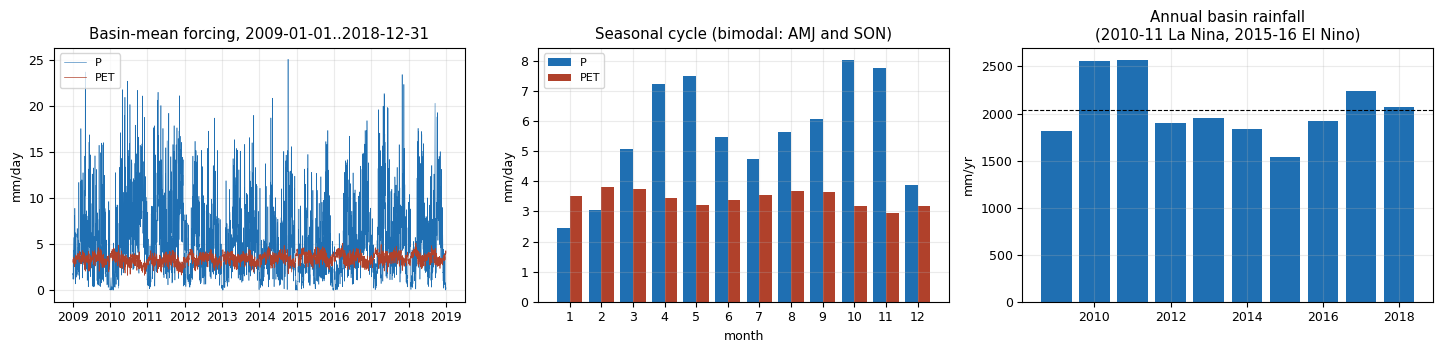

annual basin P (mm): 2009:1,813, 2010:2,559, 2011:2,571, 2012:1,904, 2013:1,950, 2014:1,834, 2015:1,534, 2016:1,921, 2017:2,241, 2018:2,070


In [4]:
with rasterio.open(PROC / 'minibacias.tif') as src:
    LAB = src.read(1); BN = src.bounds
EXT = (BN.left, BN.right, BN.bottom, BN.top)
_LUT = np.full(int(LAB.max()) + 1, np.nan, dtype='float32')


def to_grid(vals):
    '''Paint a per-minibacia vector onto the label raster (order = TOPO.ids).'''
    _LUT[:] = np.nan
    _LUT[TOPO.ids] = np.asarray(vals, dtype='float32')
    return np.where(LAB == 0, np.nan, _LUT[LAB])


fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.6))
ax[0].plot(DATES, p_bas, lw=.4, color='#1F6FB2', label='P')
ax[0].plot(DATES, e_bas, lw=.5, color='#B0412B', label='PET')
ax[0].set_ylabel('mm/day'); ax[0].legend(fontsize=8)
ax[0].set_title(f'Basin-mean forcing, {DATES[0].date()}..{DATES[-1].date()}')
mo = pd.DataFrame({'p': p_bas, 'e': e_bas}, index=DATES).groupby(DATES.month).mean()
ax[1].bar(mo.index - .2, mo.p, width=.4, color='#1F6FB2', label='P')
ax[1].bar(mo.index + .2, mo.e, width=.4, color='#B0412B', label='PET')
ax[1].set_xticks(range(1, 13)); ax[1].set_xlabel('month'); ax[1].set_ylabel('mm/day')
ax[1].set_title('Seasonal cycle (bimodal: AMJ and SON)'); ax[1].legend(fontsize=8)
ann = pd.Series(p_bas, index=DATES).groupby(DATES.year).sum()
ax[2].bar(ann.index, ann.values, color='#1F6FB2')
ax[2].axhline(ann.mean(), color='k', ls='--', lw=.8)
ax[2].set_ylabel('mm/yr'); ax[2].set_title('Annual basin rainfall\n(2010-11 La Nina, 2015-16 El Nino)')
for a in ax: a.grid(alpha=.25)
plt.tight_layout(); plt.show()
print('annual basin P (mm):', ', '.join(f'{y}:{v:,.0f}' for y, v in ann.items()))

## 2 - The uncalibrated parameter set

This is the section the calibration will argue with, so every number is placed in one of two
classes and nothing is left implicit:

* **DATA** - derived from a measurement in this project's own pipeline.
* **PRIOR** - a literature or notebook-03 value. No observed discharge was consulted.

| Parameter | Value | Class | Where it comes from | Alternative rejected, and why |
|---|---|---|---|---|
| `wm_mini` | per minibacia, from IGAC | **DATA** | `parameters.npz:Wm_mm` - nb09: IGAC AWC(texture) x depth x 10, area-weighted | A uniform `Wm = 120 mm` (the engine's default). Rejected: it discards the only soil information the project actually measured, and the measured range spans a factor of ~19, which is exactly the spatial signal a distributed model exists to use. |
| `wm_scale` | 1.0 for all 24 URH | **PRIOR** (identity) | no data | Per-URH multipliers (e.g. deeper effective storage under forest). Rejected: nb09 s.7 says explicitly that *calibration* will scale $W_m$ per URH. Inventing 24 unmeasured multipliers now would pre-empt calibration and make the baseline unfalsifiable. |
| `b` | 0.6 | **PRIOR** | nb03 s.2 worked example | MGB-IPH applications commonly use $b\approx 0.4$ (Collischonn et al. 2007). Rejected as the *baseline* value because nb03 is this project's own derivation and 0.6 is the number it reasoned with; a value taken from another basin's calibration is not a prior, it is someone else's answer. |
| `kc` | per land class: forest 1.00, shrub 0.90, grass 0.90, crop 1.00, urban 0.35, bare 0.25, water 1.05, wetland 1.05 | **PRIOR** | FAO-56 mid-season $K_c$ ranges | $k_c=1$ everywhere (literal nb03). Rejected: it gives asphalt and bare rock the same evaporative demand as closed tropical forest. Differentiating by **land class only** (8 numbers, not 24) is deliberate - soil family changes water *supply* through $W_m$, not canopy *demand*, so a soil-dependent $k_c$ would be double-counting. The cell below reports the area-weighted mean; if it is close to 1 the differentiation mostly redistributes ET rather than shifting the basin total, which is the property a baseline wants. |
| `lai` | per land class: forest 5.0, shrub 2.0, grass 1.5, crop 2.5, urban 0.5, bare/water 0.0, wetland 2.0 | **PRIOR** | typical tropical values | $\mathrm{LAI}=0$ (engine default, interception off, literal nb03). Rejected because canopy interception is a first-order term in a wet tropical basin. But this prior is **weak and probably too small** - section 4.5 measures the interception loss it produces and compares it with the 10-20 % of $P$ that field studies report for tropical forest. Reported as a known deficiency rather than tuned away. |
| `alpha_int` | 0.2 mm per unit LAI | **PRIOR** | MGB-IPH standard value | Fitting $\alpha_{int}$. Rejected: it is not separately identifiable from LAI here (only the product $\alpha_{int}\mathrm{LAI}$ enters), so calibrating both would be fitting two knobs to one number. |
| `percolation` | `'linear'`, $a_{dr}=0.06\,\mathrm{d^{-1}}$, $f_{int}=0.6$ | **PRIOR** | nb03 s.4 cell 7 | The published nonlinear MGB form (`'mgb'`: $K_{int}$, $K_{bas}$, $W_z$, $\lambda$). Rejected: four more unmeasured numbers and no more information about this basin. **$a_{dr}$ is nonetheless the parameter this baseline is most wrong about** - section 2.2 predicts the consequence *before* the run, and section 4.4 checks the prediction. |
| `reservoir` | `'exact'` | engine default | analytic solution of nb03 s.3's own $Q=Q_0e^{-t/K}$ | `'euler'` ($Q=S/K$, nb03 cell 7 literally). Rejected: unstable for $K<1$ d - and calibration will want $K_{sup}<1$ d in flashy Andean headwaters - and it gives a 24 % higher peak on nb03's own case (engine test 7c). |
| `k_sup`, `k_int`, `k_bas` | 1.5, 8, 60 days, uniform | **PRIOR** | MGB-IPH reservoir time-scale ranges | MGB-IPH's $C_S = C\cdot T_{ind}$, which scales the surface reservoir with a slope-and-area concentration-time index. Rejected: the project has never derived minibacia slope, so $T_{ind}$ would have to be invented. Uniform-and-obviously-wrong beats spatially-varying-and-secretly-invented, because calibration can see the first. |
| `tau_channel` | $\tau_i = L_i/(c\,86400)$ with $L_i=$ `reach_km`, $c = 1.0\ \mathrm{m\,s^{-1}}$ | **DATA** (length) + **PRIOR** (celerity) | `topology.npz:reach_km` (nb12: haversine centroid-to-centroid) | The engine's own `default_channel_tau`, which approximates reach length by the equivalent-circle diameter $2\sqrt{A/\pi}$ of the minibacia. Rejected because `topology.npz` carries the **real** centroid-to-centroid distance, so the approximation is unnecessary here. A uniform $\tau=0.1$ d was also rejected: reach length spans roughly a factor of 5 across the network, and the resulting mainstem traverse is a number that can be sanity-checked against reality (cell below). |
| initial state | $W = 0.4\,W_m$, $S_{bas}$ = analytic reservoir equilibrium, others 0 | **PRIOR** | engine default `w_frac`, plus the equilibrium closed form | $S_{bas}=0$. Not rejected on principle - section 3.3 *proves* the choice is irrelevant by starting from wildly different states - but a near-equilibrium $S_{bas}$ shortens the warm-up of the slowest state ($K_{bas}=60$ d), which is the one 366 days of warm-up is least able to settle. |

**Celerity $c = 1\ \mathrm{m\,s^{-1}}$.** This is the one routing prior with a checkable consequence:
it fixes the travel time from the most distant headwater to Calamar. The cell below prints it, and it
must land in the couple-of-weeks range that the ~1,500 km Magdalena mainstem actually shows. A
Manning-based celerity was rejected for the same reason Muskingum-Cunge was: it needs width, depth
and slope, none of which this project has derived.

In [5]:
LAND_NAME = {1: 'Forest', 2: 'Shrub', 3: 'Grassland', 4: 'Cropland',
             5: 'Urban', 6: 'Bare', 7: 'Water', 8: 'Wetland'}
SOIL_NAME = {1: 'Coarse', 2: 'Medium', 3: 'Fine'}
KC_LAND = {1: 1.00, 2: 0.90, 3: 0.90, 4: 1.00, 5: 0.35, 6: 0.25, 7: 1.05, 8: 1.05}
LAI_LAND = {1: 5.0, 2: 2.0, 3: 1.5, 4: 2.5, 5: 0.5, 6: 0.0, 7: 0.0, 8: 2.0}
ALPHA_INT = 0.2
B_SHAPE = 0.6
ADR = 0.06
FINT = 0.6
K_SUP, K_INT, K_BAS = 1.5, 8.0, 60.0
CELERITY_M_S = 1.0
W_FRAC0 = 0.4

URH_CODE = np.asarray(PAR['urh_id']).astype(int)
assert np.array_equal(URH_CODE, np.asarray(mgb.URH_CODES)), \
    'URH code order differs from the engine - kc/LAI would be attached to the wrong URH'
KC_URH = np.array([KC_LAND[c % 10] for c in URH_CODE])
LAI_URH = np.array([LAI_LAND[c % 10] for c in URH_CODE])
WM_MINI = PAR['Wm_mm'].astype(np.float64)
REACH_KM = TOP['reach_km'].astype(np.float64)
TAU_CH = REACH_KM * 1000.0 / (CELERITY_M_S * 86400.0)

# area weight of each URH over the whole basin (used only for reporting)
urh_area = (PAR['urh_fraction'].astype(np.float64) * A_MB[:, None]).sum(0)
urh_w = urh_area / urh_area.sum()
land_w = {l: urh_w[[i for i, c in enumerate(URH_CODE) if c % 10 == l]].sum()
          for l in sorted(LAND_NAME)}

PARAMS = mgb.MgbParams(wm_mini=WM_MINI, wm_scale=1.0, b=B_SHAPE, kc=KC_URH,
                       lai=LAI_URH, alpha_int=ALPHA_INT,
                       percolation='linear', adr=ADR, fint=FINT,
                       reservoir='exact', k_sup=K_SUP, k_int=K_INT, k_bas=K_BAS,
                       tau_channel=TAU_CH)
_ = PARAMS.expand(TOPO)          # forces every range validation in the engine
print('MgbParams accepted by the engine (all range checks passed)\n')

print(f'Wm_mm (DATA)      min {WM_MINI.min():6.1f}  p25 {np.percentile(WM_MINI,25):6.1f}  '
      f'median {np.median(WM_MINI):6.1f}  p75 {np.percentile(WM_MINI,75):6.1f}  '
      f'max {WM_MINI.max():6.1f}   area-weighted mean {np.average(WM_MINI, weights=A_MB):.1f}')
print(f'                  ratio max/min = {WM_MINI.max()/WM_MINI.min():.1f}x  '
      f'-> this is the spatial signal a uniform Wm would have thrown away')
print(f'kc  (PRIOR)       area-weighted basin mean {(urh_w*KC_URH).sum():.4f}  '
      f'-> differentiation mostly REDISTRIBUTES ET, it does not shift the basin total')
print(f'LAI (PRIOR)       area-weighted {(urh_w*LAI_URH).sum():.3f}  '
      f'=> area-weighted Simax = {ALPHA_INT*(urh_w*LAI_URH).sum():.3f} mm')
print(f'tau_channel       reach_km  median {np.median(REACH_KM):.3f} km  '
      f'(p5 {np.percentile(REACH_KM,5):.2f}, p95 {np.percentile(REACH_KM,95):.2f}, '
      f'ratio p95/p5 {np.percentile(REACH_KM,95)/np.percentile(REACH_KM,5):.1f}x)')
print(f'                  tau median {np.median(TAU_CH):.4f} d  max {TAU_CH.max():.4f} d  '
      f'({int((TAU_CH==0).sum())} zero = the outlet, reach_km = 0)')
trav = TOP['path_km_to_outlet'].max() * 1000.0 / (CELERITY_M_S * 86400.0)
print(f'  SANITY  most distant headwater is {TOP["path_km_to_outlet"].max():,.0f} km from '
      f'Calamar -> traverse {trav:.1f} days at c = {CELERITY_M_S} m/s')
print(f'          the ~1,500 km Magdalena mainstem takes ~2-3 weeks in reality, so this '
      f'prior is the right ORDER; it is not a measurement')

print('\nbasin land-cover composition (area-weighted, from urh_fraction):')
for l, w in sorted(land_w.items(), key=lambda kv: -kv[1]):
    print(f'   {LAND_NAME[l]:<10s} {100*w:6.2f} %   kc {KC_LAND[l]:.2f}  LAI {LAI_LAND[l]:.1f}'
          f'  Simax {ALPHA_INT*LAI_LAND[l]:.2f} mm')

MgbParams accepted by the engine (all range checks passed)

Wm_mm (DATA)      min   13.5  p25   48.3  median   72.6  p75  116.4  max  255.0   area-weighted mean 84.7
                  ratio max/min = 18.9x  -> this is the spatial signal a uniform Wm would have thrown away
kc  (PRIOR)       area-weighted basin mean 0.9577  -> differentiation mostly REDISTRIBUTES ET, it does not shift the basin total
LAI (PRIOR)       area-weighted 3.460  => area-weighted Simax = 0.692 mm
tau_channel       reach_km  median 5.074 km  (p5 3.02, p95 8.60, ratio p95/p5 2.8x)
                  tau median 0.0587 d  max 0.2302 d  (1 zero = the outlet, reach_km = 0)
  SANITY  most distant headwater is 1,426 km from Calamar -> traverse 16.5 days at c = 1.0 m/s
          the ~1,500 km Magdalena mainstem takes ~2-3 weeks in reality, so this prior is the right ORDER; it is not a measurement

basin land-cover composition (area-weighted, from urh_fraction):
   Forest      55.77 %   kc 1.00  LAI 5.0  Simax 1.00 mm
   G

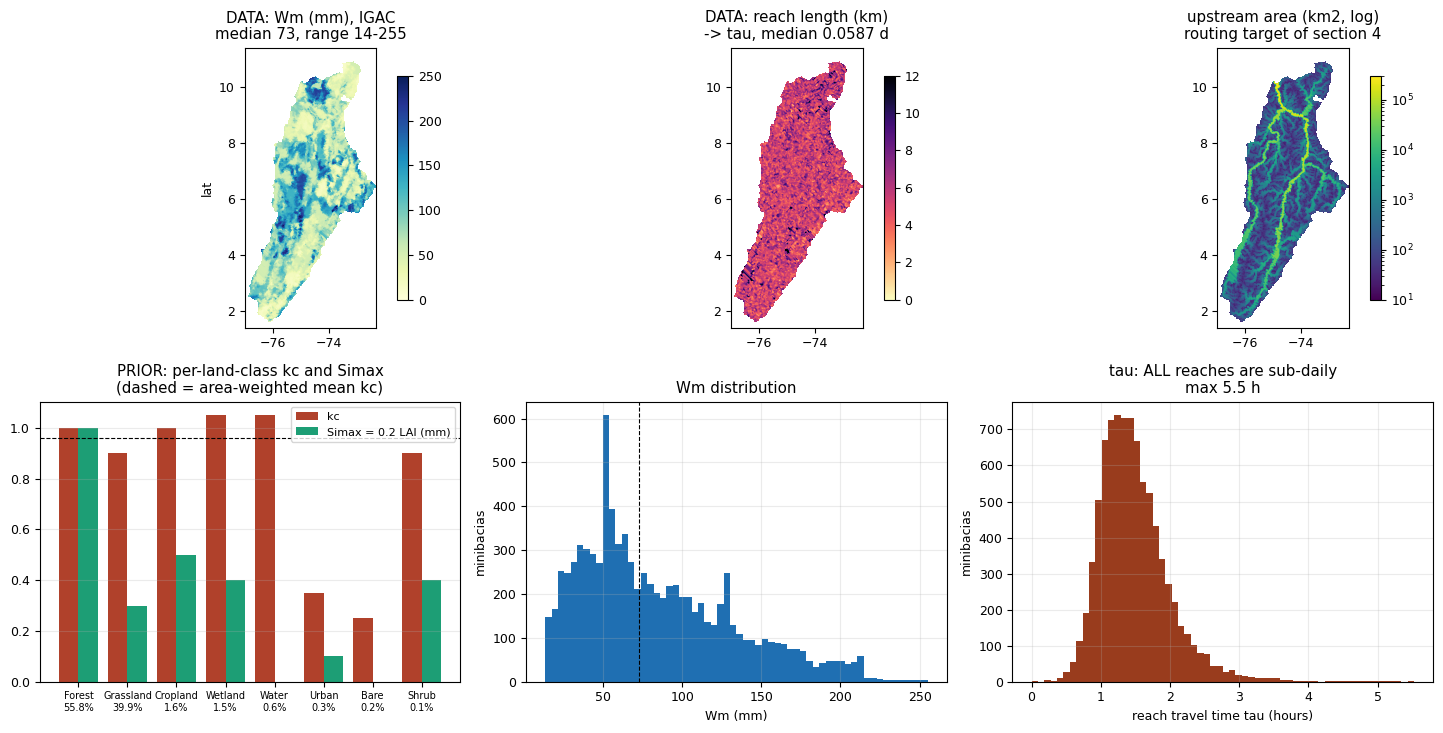

In [6]:
fig = plt.figure(figsize=(14.5, 7.4))
a = fig.add_subplot(2, 3, 1)
im = a.imshow(to_grid(WM_MINI), extent=EXT, cmap='YlGnBu', vmin=0, vmax=250)
a.set_title(f'DATA: Wm (mm), IGAC\nmedian {np.median(WM_MINI):.0f}, range '
            f'{WM_MINI.min():.0f}-{WM_MINI.max():.0f}')
a.set_ylabel('lat'); plt.colorbar(im, ax=a, shrink=.8)
a = fig.add_subplot(2, 3, 2)
im = a.imshow(to_grid(REACH_KM), extent=EXT, cmap='magma_r', vmin=0, vmax=12)
a.set_title(f'DATA: reach length (km)\n-> tau, median {np.median(TAU_CH):.4f} d')
plt.colorbar(im, ax=a, shrink=.8)
a = fig.add_subplot(2, 3, 3)
im = a.imshow(to_grid(TOP['upstream_area_km2']), extent=EXT, cmap='viridis',
              norm=LogNorm(vmin=10, vmax=3e5))
a.set_title('upstream area (km2, log)\nrouting target of section 4')
plt.colorbar(im, ax=a, shrink=.8)

a = fig.add_subplot(2, 3, 4)
ordl = sorted(LAND_NAME, key=lambda l: -land_w[l])
xx = np.arange(len(ordl))
a.bar(xx - .2, [KC_LAND[l] for l in ordl], .4, color='#B0412B', label='kc')
a.bar(xx + .2, [ALPHA_INT * LAI_LAND[l] for l in ordl], .4, color='#1D9E75',
      label='Simax = 0.2 LAI (mm)')
a.axhline((urh_w * KC_URH).sum(), color='k', ls='--', lw=.8)
a.set_xticks(xx); a.set_xticklabels([f'{LAND_NAME[l]}\n{100*land_w[l]:.1f}%' for l in ordl],
                                     fontsize=7, rotation=0)
a.set_title('PRIOR: per-land-class kc and Simax\n(dashed = area-weighted mean kc)')
a.legend(fontsize=8); a.grid(alpha=.25, axis='y')
a = fig.add_subplot(2, 3, 5)
a.hist(WM_MINI, bins=60, color='#1F6FB2')
a.axvline(np.median(WM_MINI), color='k', ls='--', lw=.8)
a.set_xlabel('Wm (mm)'); a.set_ylabel('minibacias'); a.set_title('Wm distribution')
a.grid(alpha=.25)
a = fig.add_subplot(2, 3, 6)
a.hist(TAU_CH * 24, bins=60, color='#993C1D')
a.set_xlabel('reach travel time tau (hours)'); a.set_ylabel('minibacias')
a.set_title(f'tau: ALL reaches are sub-daily\nmax {TAU_CH.max()*24:.1f} h')
a.grid(alpha=.25)
plt.tight_layout(); plt.show()

### 2.2 - A prediction registered *before* the run

Rule 2 says every headline number gets a second, independent derivation. For the single most
important output - the basin runoff coefficient - the independent derivation is done **now**, from
the parameters alone, with no time loop and no engine code. That makes it a genuine prediction
rather than a post-hoc rationalisation.

Set the soil column to steady state under the *annual mean* forcing, with interception switched off
so the algebra is exact rather than approximate (rain-day intermittency is what makes interception
resist a mean-field treatment). Writing $x=W/W_m$, the balance $P_{thr}=D_{sup}+ET+\text{drain}$
becomes, per (minibacia, URH) cell:

$$\bar P\,(1-x)^{b} \;=\; k_c\,\overline{PET}\,x \;+\; a_{dr}\,W_m\,x$$

because $1-A_{sat}=(1-x)^b$ is the fraction of throughfall that infiltrates. Solve per cell by
bisection, area-weight, and the predicted runoff coefficient is $1-\overline{ET}/\bar P$.

This is a **mean-field** estimate: it ignores rainfall intermittency and the seasonal cycle, and
$A_{sat}$ is concave in $W$, so Jensen's inequality guarantees a gap. The prediction is therefore
"same ballpark", not "same digits", and section 4.4 states the gap rather than hiding it.

The number that matters for judging it: notebook 12 measured the observed runoff depth at Calamar
(`manifest.json:calamar_runoff_depth_mm_yr`), which the cell below converts into an observed
coefficient.

In [7]:
Pm_cell = P_ALL.mean(0)[TOPO.cell_mini]
Em_cell = E_ALL.mean(0)[TOPO.cell_mini]
Wm_cell = WM_MINI[TOPO.cell_mini]
kc_cell = KC_URH[TOPO.cell_urh]
A_CELL = TOPO.cell_area_km2


def _resid(x):
    return Pm_cell * np.power(np.maximum(1.0 - x, 0.0), B_SHAPE) - kc_cell * Em_cell * x - ADR * Wm_cell * x


lo = np.zeros_like(Pm_cell); hi = np.ones_like(Pm_cell)
assert np.all(_resid(lo) >= 0) and np.all(_resid(hi) <= 0), 'root not bracketed in [0,1]'
for _ in range(200):
    mid = .5 * (lo + hi)
    pos = _resid(mid) > 0
    lo = np.where(pos, mid, lo); hi = np.where(pos, hi, mid)
X_MF = .5 * (lo + hi)
print(f'bisection converged: max |residual| = {np.abs(_resid(X_MF)).max():.3e} mm/day')

et_mf = (kc_cell * Em_cell * X_MF * A_CELL).sum() / A_TOT * 365.25
p_mf = (Pm_cell * A_CELL).sum() / A_TOT * 365.25
PRED_COEFF = 1.0 - et_mf / p_mf
OBS_COEFF = MAN['validation']['calamar_runoff_depth_mm_yr'] / MAN['validation']['basin_mean_P_mm_yr']
print(f'\nMEAN-FIELD PREDICTION (no time loop, interception off)')
print(f'  equilibrium W/Wm      area-weighted {np.average(X_MF, weights=A_CELL):.4f} '
      f'(p10 {np.percentile(X_MF,10):.3f}, p90 {np.percentile(X_MF,90):.3f})')
print(f'  P                     {p_mf:,.1f} mm/yr')
print(f'  ET                    {et_mf:,.1f} mm/yr')
print(f'  => runoff coefficient {PRED_COEFF:.4f}   (runoff {p_mf-et_mf:,.1f} mm/yr)')
print(f'\nOBSERVED (notebook 12, Calamar)')
print(f'  runoff depth          {MAN["validation"]["calamar_runoff_depth_mm_yr"]:,.1f} mm/yr')
print(f'  => runoff coefficient {OBS_COEFF:.4f}')
print(f'\nPREDICTED / OBSERVED   {PRED_COEFF/OBS_COEFF:.3f}  -> the parameter set is expected to '
      f'over-produce runoff by ~{100*(PRED_COEFF/OBS_COEFF-1):.0f} %')
print(f'  Implied ET deficit: the baseline evaporates {et_mf:,.0f} mm/yr where a wet tropical')
print(f'  basin with PET = {e_bas.sum()/YEARS:,.0f} mm/yr and P = {p_bas.sum()/YEARS:,.0f} mm/yr '
      f'should evaporate roughly')
print(f'  {MAN["validation"]["basin_mean_P_mm_yr"]-MAN["validation"]["calamar_runoff_depth_mm_yr"]:,.0f}'
      f' mm/yr (= observed P - observed Q).')
print(f'\nMECHANISM: adr = {ADR}/day drains the soil so fast that W settles near '
      f'{100*np.average(X_MF, weights=A_CELL):.0f} % of Wm;')
print(f'  ET = kc PET W/Wm is proportional to W/Wm, so a soil kept dry cannot evaporate. '
      f'The\n  prediction is therefore that BETA (bias) will be the dominant KGE loss, and that '
      f'adr\n  is the first knob calibration should turn. Section 5 tests that prediction.')

bisection converged: max |residual| = 4.441e-15 mm/day

MEAN-FIELD PREDICTION (no time loop, interception off)
  equilibrium W/Wm      area-weighted 0.4656 (p10 0.310, p90 0.631)
  P                     2,039.9 mm/yr
  ET                    564.3 mm/yr
  => runoff coefficient 0.7234   (runoff 1,475.6 mm/yr)

OBSERVED (notebook 12, Calamar)
  runoff depth          912.4 mm/yr
  => runoff coefficient 0.4401

PREDICTED / OBSERVED   1.644  -> the parameter set is expected to over-produce runoff by ~64 %
  Implied ET deficit: the baseline evaporates 564 mm/yr where a wet tropical
  basin with PET = 1,257 mm/yr and P = 2,040 mm/yr should evaporate roughly
  1,161 mm/yr (= observed P - observed Q).

MECHANISM: adr = 0.06/day drains the soil so fast that W settles near 47 % of Wm;
  ET = kc PET W/Wm is proportional to W/Wm, so a soil kept dry cannot evaporate. The
  prediction is therefore that BETA (bias) will be the dominant KGE loss, and that adr
  is the first knob calibration should turn.

## 3 - Warm-up: 2008, taken from inside the bundle

`manifest.json` states the situation and the decision: `warmup_available_days = 0`, because the
model period now *starts* at the start of the rainfall record. **That is not a gap.** The spin-up is
taken from inside the period: 2008 warms up, 2009-2018 is scored. Nothing is invented.

**What changed against v1, and why it is strictly better.** The v1 run had 366 days of 2008 rainfall
sitting outside a 2009-2017 bundle and **no 2008 PET at all** (only 108 of the 132 ERA5-Land mosaics
existed), so its warm-up ran real rainfall against a (month, day)-median PET climatology - a stated,
defensible, but invented input. All 132 mosaics now exist, so 2008 PET is **measured**, and the
warm-up runs measured forcing on both fields. The climatology helper, its leap-year trap and its
median-vs-mean argument are therefore retired rather than carried along.

**Rejected alternatives, still.**

* *A cold start into 2009 with no warm-up.* Section 3.3 measures how long the state takes to forget
  its initial value; a cold start puts that transient inside the scored period.
* *Warming up on 2008 and also scoring it.* The warm-up year cannot be scored without the score
  depending on the initial condition, which is precisely what 3.3 exists to eliminate. One year is
  the price, and the record is long enough to pay it.
* *Two warm-up years (2008-2009), scoring 2010-2018.* It would settle the groundwater store harder,
  but it costs the 2009 half of the 2009-2010 El Nino and buys nothing 3.3 does not already prove.

**The real risk, and how it is handled.** 366 days is only ~6 e-folding times of the $K_{bas}=60$ d
groundwater reservoir, so the slowest state is the one most likely to still be drifting. Two things
are therefore done rather than assumed: the drift over the last 90 warm-up days is **measured**
(3.2), and the whole warm-up is repeated from three deliberately incompatible initial states to see
whether 2009 discharge depends on any of them (3.3). Rule 5: a warm-up that merely *looks* settled is
the classic way to ship a bias.

warm-up window 2008-01-01 .. 2008-12-31  366 days (leap year: 29-Feb present = True)
  both fields MEASURED - no climatology, no stand-in
  NaN P 0 PET 0, negatives P 0 PET 0, max cell-day P 215.0 mm  PET 7.45 mm

warm-up forcing (basin mean):  P 2,409 mm/yr  (2009-18 mean 2,040)
                               PET 1,201 mm/yr  (2009-18 mean 1,257)   difference -4.49 %
  2008 was +18.1 % wetter than the 2009-18 mean, so the state enters 2009 on the wet side
  RECHECK 3z  ERA5-Land PET sanity for the warm-up year: basin-mean daily PET 3.280 mm/day
              (the scored period runs 3.441 mm/day; a warm-up year differing by more than
              a few per cent would say the 2008 mosaics are not the same product as the rest)


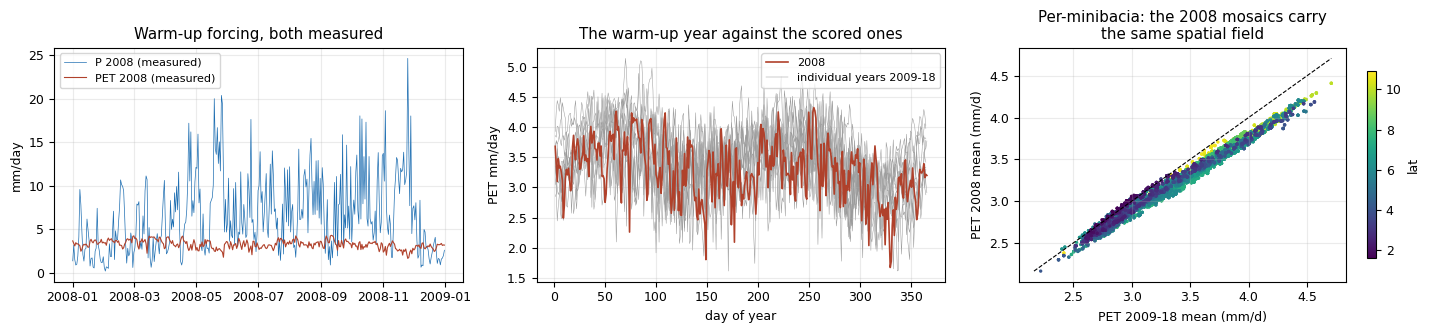

spatial correlation between the 2008 mean PET field and the 2009-18 mean: r = 0.991377
  This is a REAL check now, not a tautology. In v1 the warm-up PET was a temporal median of
  the scored years, so r ~ 1 was guaranteed by construction. Here 2008 is an independent
  year of ERA5-Land, and a low r would mean the rebuilt 2008 mosaics (including the one
  found internally corrupt and rebuilt) are not spatially consistent with the rest.


In [8]:
print(f'warm-up window {D_WU[0].date()} .. {D_WU[-1].date()}  {len(D_WU)} days '
      f'(leap year: 29-Feb present = '
      f'{(229 in set((np.asarray(D_WU.month)*100+np.asarray(D_WU.day)).tolist()))})')
print(f'  both fields MEASURED - no climatology, no stand-in')
print(f'  NaN P {int(np.isnan(P_WU).sum())} PET {int(np.isnan(E_WU).sum())}, '
      f'negatives P {int((P_WU<0).sum())} PET {int((E_WU<0).sum())}, '
      f'max cell-day P {P_WU.max():.1f} mm  PET {E_WU.max():.2f} mm')

print(f'\nwarm-up forcing (basin mean):  P {p_wu_bas.sum():,.0f} mm/yr  '
      f'(2009-18 mean {p_bas.sum()/YEARS:,.0f})')
print(f'                               PET {e_wu_bas.sum():,.0f} mm/yr  '
      f'(2009-18 mean {e_bas.sum()/YEARS:,.0f})   '
      f'difference {100*(e_wu_bas.sum()/(e_bas.sum()/YEARS)-1):+.2f} %')
_wetdry = 'wetter' if p_wu_bas.sum() > p_bas.sum() / YEARS else 'drier'
print(f'  2008 was {100*(p_wu_bas.sum()/(p_bas.sum()/YEARS)-1):+.1f} % {_wetdry} than the '
      f'2009-18 mean, so the state enters 2009 on the '
      f'{"wet" if _wetdry == "wetter" else "dry"} side')
print(f'  RECHECK 3z  ERA5-Land PET sanity for the warm-up year: basin-mean daily PET '
      f'{e_wu_bas.mean():.3f} mm/day')
print(f'              (the scored period runs {e_bas.mean():.3f} mm/day; a warm-up year '
      f'differing by more than\n              a few per cent would say the 2008 mosaics are not '
      f'the same product as the rest)')

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.4))
ax[0].plot(D_WU, p_wu_bas, lw=.5, color='#1F6FB2', label='P 2008 (measured)')
ax[0].plot(D_WU, e_wu_bas, lw=.8, color='#B0412B', label='PET 2008 (measured)')
ax[0].set_ylabel('mm/day'); ax[0].legend(fontsize=8); ax[0].set_title('Warm-up forcing, both measured')
ax[1].plot(np.arange(1, len(e_wu_bas) + 1), e_wu_bas, lw=1.2, color='#B0412B', label='2008')
for y in range(2009, 2019):
    s = pd.Series(e_bas, index=DATES)
    s = s[s.index.year == y]
    ax[1].plot(np.arange(1, len(s) + 1), s.values, lw=.35, color='0.6', zorder=0)
ax[1].plot([], [], lw=.35, color='0.6', label='individual years 2009-18')
ax[1].set_xlabel('day of year'); ax[1].set_ylabel('PET mm/day')
ax[1].set_title('The warm-up year against the scored ones'); ax[1].legend(fontsize=8)
sc = ax[2].scatter(E_ALL.mean(0), E_WU.mean(0), s=2, c=TOP['centroid_lat'], cmap='viridis')
lim = [min(E_ALL.mean(0).min(), E_WU.mean(0).min()), max(E_ALL.mean(0).max(), E_WU.mean(0).max())]
ax[2].plot(lim, lim, 'k--', lw=.8)
ax[2].set_xlabel('PET 2009-18 mean (mm/d)'); ax[2].set_ylabel('PET 2008 mean (mm/d)')
ax[2].set_title('Per-minibacia: the 2008 mosaics carry\nthe same spatial field')
plt.colorbar(sc, ax=ax[2], shrink=.8, label='lat')
for a in ax: a.grid(alpha=.25)
plt.tight_layout(); plt.show()
r_sp = np.corrcoef(E_ALL.mean(0), E_WU.mean(0))[0, 1]
print(f'spatial correlation between the 2008 mean PET field and the 2009-18 mean: '
      f'r = {r_sp:.6f}')
print(f'  This is a REAL check now, not a tautology. In v1 the warm-up PET was a temporal median of')
print(f'  the scored years, so r ~ 1 was guaranteed by construction. Here 2008 is an independent')
print(f'  year of ERA5-Land, and a low r would mean the rebuilt 2008 mosaics (including the one')
print(f'  found internally corrupt and rebuilt) are not spatially consistent with the rest.')

### 3.1 - The initial state, and the closed form behind $S_{bas}$

A linear reservoir released with the exact scheme reaches, under a constant inflow $I$, the
equilibrium storage $S^\* = I/(1-e^{-\Delta t/K})$. The mean-field solution of section 2.2 already
gives the equilibrium drainage $\text{drain}=a_{dr}W$, of which $(1-f_{int})$ goes to groundwater, so
$S_{bas}^\*$ can be written down instead of guessed. The same closed form is used for $S_{int}$ and
$S_{sup}$, which settle so fast ($K=8$ and $1.5$ d) that it makes no practical difference - but it
costs nothing and removes an arbitrary zero.

The engine's `MgbState.initial` only exposes a scalar `s_bas_mm`, so the state is built with it and
then the other two reservoirs are set explicitly. Rejected alternative: all reservoirs at zero, which
is what a bare cold start does - kept as one of the three probes in 3.3 precisely so its cost is
measured rather than assumed.

In [9]:
drain_eq = ADR * X_MF * Wm_cell                       # mm/day per cell, mean-field
d_bas_eq = np.bincount(TOPO.cell_mini, weights=(1 - FINT) * drain_eq * TOPO.cell_frac,
                       minlength=TOPO.n_mini)
d_int_eq = np.bincount(TOPO.cell_mini, weights=FINT * drain_eq * TOPO.cell_frac,
                       minlength=TOPO.n_mini)
c_bas = -np.expm1(-1.0 / K_BAS); c_int = -np.expm1(-1.0 / K_INT)
S_BAS0 = d_bas_eq / c_bas
S_INT0 = d_int_eq / c_int
print(f'closed-form equilibrium storages (mean-field inflow):')
print(f'  Dbas {np.average(d_bas_eq, weights=A_MB):.4f} mm/d -> S_bas* '
      f'{np.average(S_BAS0, weights=A_MB):.2f} mm   (K_bas {K_BAS} d, release coef {c_bas:.6f})')
print(f'  Dint {np.average(d_int_eq, weights=A_MB):.4f} mm/d -> S_int* '
      f'{np.average(S_INT0, weights=A_MB):.2f} mm   (K_int {K_INT} d, release coef {c_int:.6f})')


def make_state(w_frac, s_bas, s_int=None):
    st = mgb.MgbState.initial(TOPO, PARAMS, w_frac=w_frac, s_bas_mm=0.0)
    st.s_bas = np.broadcast_to(np.asarray(s_bas, dtype=float), (TOPO.n_mini,)).astype(float).copy()
    if s_int is not None:
        st.s_int = np.broadcast_to(np.asarray(s_int, dtype=float),
                                   (TOPO.n_mini,)).astype(float).copy()
    return st


STARTS = {
    'baseline  (W=0.40 Wm, S_bas=S*, S_int=S*)': make_state(W_FRAC0, S_BAS0, S_INT0),
    'dry cold  (W=0.05 Wm, all reservoirs 0)': make_state(0.05, 0.0),
    'wet warm  (W=0.95 Wm, S_bas=4 S*)': make_state(0.95, 4.0 * S_BAS0, 4.0 * S_INT0),
}
for k, st in STARTS.items():
    print(f'  {k:<45s} storage {st.storage_volume(TOPO)/A_TOT:8.2f} mm')

closed-form equilibrium storages (mean-field inflow):
  Dbas 0.8574 mm/d -> S_bas* 51.87 mm   (K_bas 60.0 d, release coef 0.016529)
  Dint 1.2860 mm/d -> S_int* 10.94 mm   (K_int 8.0 d, release coef 0.117503)
  baseline  (W=0.40 Wm, S_bas=S*, S_int=S*)     storage    96.69 mm
  dry cold  (W=0.05 Wm, all reservoirs 0)       storage     4.23 mm
  wet warm  (W=0.95 Wm, S_bas=4 S*)             storage   331.71 mm


In [10]:
# storage trajectory of the baseline warm-up, day by day, tracked OUTSIDE the engine by
# stepping it one day at a time. This is slower than one call but it is the only way to see
# the state settle, and it doubles as a restart-exactness check against the single call.
COMPS = ('canopy', 'soil W', 'S_sup', 'S_int', 'S_bas', 'S_channel')


def storage_components(st):
    return np.array([
        np.dot(st.sc, TOPO.cell_area_km2) / A_TOT,
        np.dot(st.w, TOPO.cell_area_km2) / A_TOT,
        np.dot(st.s_sup, A_MB) / A_TOT,
        np.dot(st.s_int, A_MB) / A_TOT,
        np.dot(st.s_bas, A_MB) / A_TOT,
        st.s_ch.sum() / A_TOT,
    ])


t0 = time.perf_counter()
st_step = STARTS['baseline  (W=0.40 Wm, S_bas=S*, S_int=S*)'].copy()
traj = [storage_components(st_step)]
q_step = np.empty(len(D_WU))
for t in range(len(D_WU)):
    r1 = mgb.simulate(TOPO, PARAMS, P_WU[t:t + 1], E_WU[t:t + 1], state=st_step,
                      record_ids=[int(TOPO.ids[TOPO.outlets[0]])], dates=D_WU[t:t + 1])
    st_step = r1.state
    q_step[t] = r1.q_m3s[0, 0]
    traj.append(storage_components(st_step))
TRAJ = np.array(traj)
print(f'day-by-day warm-up: {time.perf_counter()-t0:.1f} s for {len(D_WU)} single-day calls')

WU_RES = {}
for name, st in STARTS.items():
    WU_RES[name] = mgb.simulate(TOPO, PARAMS, P_WU, E_WU, state=st,
                                record_ids=[int(TOPO.ids[TOPO.outlets[0]])], dates=D_WU)
    print(f'  one-shot warm-up "{name.split("(")[0].strip()}": '
          f'{WU_RES[name].wall_time_s:.1f} s, backend {WU_RES[name].routing_backend}')

base_key = 'baseline  (W=0.40 Wm, S_bas=S*, S_int=S*)'
dq = np.abs(q_step - WU_RES[base_key].q_m3s[:, 0].astype(np.float64))
print(f'\nRECHECK 3a  366 single-day restarts vs one 366-day call:')
print(f'  max |dQ| at the outlet = {dq.max():.3e} m3/s  '
      f'(relative to mean {q_step.mean():,.0f} m3/s: {dq.max()/q_step.mean():.2e})')
print(f'  final storage: stepped {TRAJ[-1].sum():.6f} mm, one-shot '
      f'{WU_RES[base_key].state.storage_volume(TOPO)/A_TOT:.6f} mm, diff '
      f'{abs(TRAJ[-1].sum()-WU_RES[base_key].state.storage_volume(TOPO)/A_TOT):.3e} mm')
assert dq.max() / max(q_step.mean(), 1.0) < 1e-6, 'restart is not exact'

day-by-day warm-up: 7.4 s for 366 single-day calls


  one-shot warm-up "baseline": 1.2 s, backend numba


  one-shot warm-up "dry cold": 1.1 s, backend numba


  one-shot warm-up "wet warm": 1.3 s, backend numba

RECHECK 3a  366 single-day restarts vs one 366-day call:
  max |dQ| at the outlet = 0.000e+00 m3/s  (relative to mean 14,573 m3/s: 0.00e+00)
  final storage: stepped 78.593866 mm, one-shot 78.593866 mm, diff 0.000e+00 mm


### 3.2 - Has the state stabilised? Measured, not asserted

Two numbers per component, over the **last 90 days** of the warm-up:

* the **OLS trend** in mm/day, and its 90-day extrapolation as a percentage of the component's own
  size - i.e. "if the last 90 days continued, how much would this store change";
* the residual after removing the seasonal signal is not attempted; instead the trend is compared
  against the component's own seasonal swing over the same window, because in a bimodal-rainfall
  basin a *zero* trend is not what settling looks like. A store that has forgotten its initial value
  oscillates with the rain; one that has not, slides monotonically. The diagnostic that separates
  them is trend / seasonal-swing, and that ratio is what is reported.

drift over the last 90 days of the 366-day warm-up
component     end (mm)   trend mm/d  90d extrap  swing (mm)  |trend*90|/swing
canopy          0.0000    3.176e-06      0.0003      0.0109             0.026
soil W         15.9518   -2.502e-01    -22.5171     42.9858             0.524
S_sup           0.6128   -4.374e-02     -3.9363      9.6625             0.407
S_int           6.1213   -3.371e-02     -3.0343      8.8803             0.342
S_bas          55.9038    3.770e-02      3.3930     10.2476             0.331
S_channel       0.0042   -4.681e-05     -0.0042      0.0165             0.256

TOTAL storage: end 78.5939 mm, trend -2.900e-01 mm/d, 90-day extrapolation -26.0986 mm = 33.207 % of the store
  seasonal swing of total storage over the same 90 d: 68.763 mm -> |trend*90| / swing = 0.380
  slowest-settling component (largest trend/swing): soil W, ratio 0.524
  S_bas ratio 0.331 - and note it is the ONLY component whose trend is POSITIVE
  (+3.77e-02 mm/d), i.e. the groundwater stor

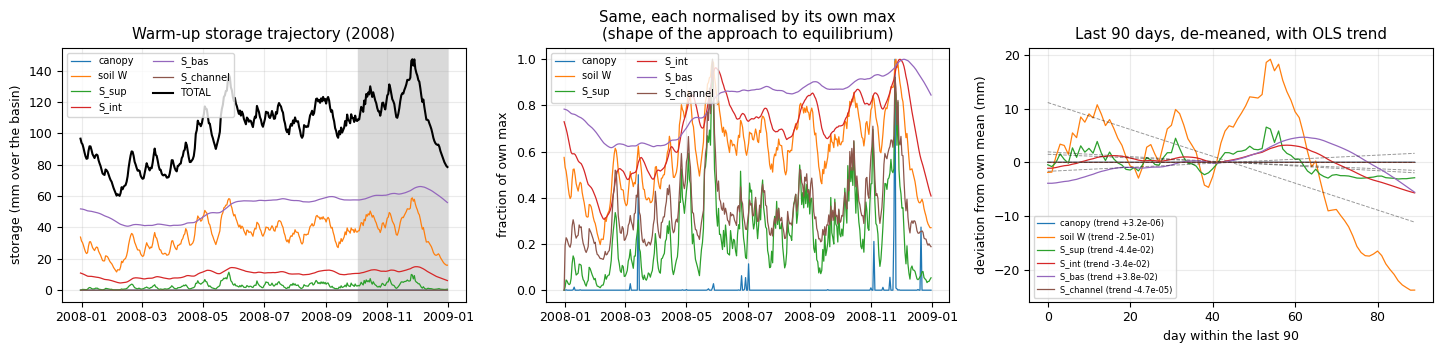

In [11]:
LAST = 90
tt = np.arange(LAST, dtype=float)
print(f'drift over the last {LAST} days of the {len(D_WU)}-day warm-up')
print(f'{"component":<11s} {"end (mm)":>10s} {"trend mm/d":>12s} {"90d extrap":>11s} '
      f'{"swing (mm)":>11s} {"|trend*90|/swing":>17s}')
drift_rows = []
for i, nm in enumerate(COMPS):
    y = TRAJ[-LAST:, i]
    sl, ic = np.polyfit(tt, y, 1)
    swing = y.max() - y.min()
    ext = sl * LAST
    ratio = abs(ext) / swing if swing > 0 else np.nan
    print(f'{nm:<11s} {y[-1]:10.4f} {sl:12.3e} {ext:11.4f} {swing:11.4f} {ratio:17.3f}')
    drift_rows.append(dict(component=nm, end_mm=y[-1], trend_mm_per_day=sl,
                           extrap_90d_mm=ext, seasonal_swing_mm=swing, ratio=ratio))
DRIFT = pd.DataFrame(drift_rows)
tot = TRAJ[-LAST:].sum(1)
sl_t, _ = np.polyfit(tt, tot, 1)
print(f'\nTOTAL storage: end {tot[-1]:.4f} mm, trend {sl_t:.3e} mm/d, 90-day extrapolation '
      f'{sl_t*LAST:+.4f} mm = {100*abs(sl_t*LAST)/tot[-1]:.3f} % of the store')
print(f'  seasonal swing of total storage over the same 90 d: {tot.max()-tot.min():.3f} mm '
      f'-> |trend*90| / swing = {abs(sl_t*LAST)/(tot.max()-tot.min()):.3f}')
slow = DRIFT.loc[DRIFT.ratio.idxmax()]
print(f'  slowest-settling component (largest trend/swing): {slow.component}, ratio '
      f'{slow.ratio:.3f}')
print(f'  S_bas ratio {float(DRIFT.loc[DRIFT.component=="S_bas","ratio"].iloc[0]):.3f} - and note '
      f'it is the ONLY component whose trend is POSITIVE\n  ({float(DRIFT.loc[DRIFT.component=="S_bas","trend_mm_per_day"].iloc[0]):+.2e} mm/d), i.e. '
      f'the groundwater store is still FILLING while everything\n  else drains. That is the '
      f'signature of the slowest reservoir (K_bas = 60 d) not yet\n  being in equilibrium with '
      f'the wet 2008 it was fed.')
print(f'\n  READ THE TOTAL HONESTLY: a 90-day extrapolation of '
      f'{100*abs(sl_t*LAST)/tot[-1]:.0f} % of the store looks alarming, but the')
print(f'  last {LAST} days of the warm-up are {D_WU[-LAST].strftime("%d-%b")} to '
      f'{D_WU[-1].strftime("%d-%b")}, i.e. the descent into the Dec-Feb dry')
print(f'  season. A settled state in a bimodal basin does NOT have zero trend - it tracks the '
      f'rain.')
print(f'  The trend-to-swing ratios above are all < 1, which is what distinguishes "following '
      f'the\n  season" from "still sliding towards equilibrium". Section 3.3 settles the question '
      f'the\n  only way that is decisive: by changing the initial state and seeing whether 2009 '
      f'notices.')

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.6))
# TRAP: TRAJ has one extra row (the initial state), so the x axis needs one extra day at the
# front. np.concatenate([[Timestamp], DatetimeIndex.to_numpy()]) does NOT do that - it builds
# an OBJECT array whose first element is a Timestamp and whose rest are raw int64 nanoseconds
# (1.199e18), which matplotlib then tries to read as day ordinals and raises OverflowError.
# DatetimeIndex.insert keeps datetime64[ns].
dwu = D_WU.insert(0, D_WU[0] - pd.Timedelta('1D'))
assert dwu.dtype.kind == 'M' and len(dwu) == TRAJ.shape[0]
for i, nm in enumerate(COMPS):
    ax[0].plot(dwu, TRAJ[:, i], lw=.9, label=nm)
ax[0].plot(dwu, TRAJ.sum(1), lw=1.5, color='k', label='TOTAL')
ax[0].set_ylabel('storage (mm over the basin)'); ax[0].legend(fontsize=7, ncol=2)
ax[0].set_title('Warm-up storage trajectory (2008)')
ax[0].axvspan(dwu[-LAST], dwu[-1], color='0.85', zorder=0)
for i, nm in enumerate(COMPS):
    y = TRAJ[:, i]
    ax[1].plot(dwu, y / max(abs(y).max(), 1e-12), lw=.9, label=nm)
ax[1].set_title('Same, each normalised by its own max\n(shape of the approach to equilibrium)')
ax[1].legend(fontsize=7, ncol=2); ax[1].set_ylabel('fraction of own max')
for i, nm in enumerate(COMPS):
    y = TRAJ[-LAST:, i]
    sl, ic = np.polyfit(tt, y, 1)
    ax[2].plot(tt, y - y.mean(), lw=.9, label=f'{nm} (trend {sl:+.1e})')
    ax[2].plot(tt, sl * tt + ic - y.mean(), lw=.7, ls='--', color='k', alpha=.4)
ax[2].set_xlabel(f'day within the last {LAST}'); ax[2].set_ylabel('deviation from own mean (mm)')
ax[2].set_title(f'Last {LAST} days, de-meaned, with OLS trend'); ax[2].legend(fontsize=6)
for a in ax: a.grid(alpha=.25)
plt.tight_layout(); plt.show()

### 3.3 - The test that actually matters: does 2009 remember where it started?

Drift statistics can be made to look good by a warm-up that is simply stuck. The decisive test is
different: run the *same* warm-up from three deliberately incompatible initial states, then run the
first scored year from each end-state and compare the discharge. If the three 2009 hydrographs are
indistinguishable, the initial condition has been forgotten, whatever the drift statistic says.

The three probes span the physically admissible range: a nearly empty soil with all reservoirs at
zero, the closed-form near-equilibrium baseline, and a nearly saturated soil with reservoirs at four
times equilibrium. The tolerance is set at **1 % of the mean flow**, because that is well below the
uncertainty of the observations the run will be scored against (`docs/17`).

2009 discharge at the outlet (minibacia 2470, Calamar), 365 days, mean 10,342 m3/s
initial state                                  end-of-warmup    max|dQ|  % of mean  day-365 %
baseline  (W=0.40 Wm, S_bas=S*, S_int=S*)             78.594      0.000     0.0000     0.0000
dry cold  (W=0.05 Wm, all reservoirs 0)               78.460      6.576     0.0636     0.0003
wet warm  (W=0.95 Wm, S_bas=4 S*)                     78.969     18.471     0.1786     0.0008

WORST divergence across the three starts: 0.1786 % of mean flow
  initial-storage spread entering the warm-up: 331.7 mm vs 4.2 mm (factor 78)
  VERDICT: 366 days of warm-up erases a storage spread of that size to below 1 % of
  mean flow, so the scored period does not depend on the initial condition. The
  residual groundwater drift found in 3.2 is real but immaterial at this tolerance.


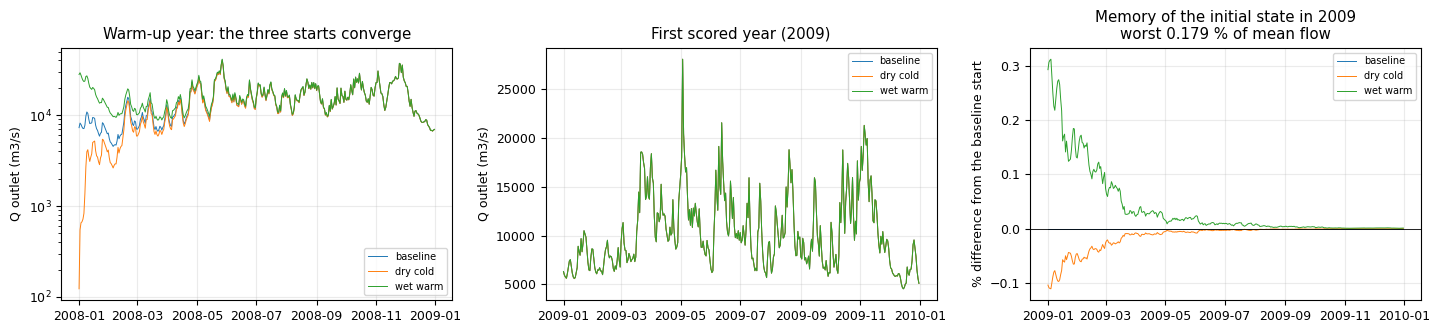

In [12]:
OUT_ID = int(TOPO.ids[TOPO.outlets[0]])
n2009 = int((DATES.year == 2009).sum())
Q09 = {}
for name, st in STARTS.items():
    r2 = mgb.simulate(TOPO, PARAMS, P_ALL[:n2009], E_ALL[:n2009], state=WU_RES[name].state,
                      record_ids=[OUT_ID], dates=DATES[:n2009])
    Q09[name] = r2.q_m3s[:, 0].astype(np.float64)
q_ref = Q09[base_key]
print(f'2009 discharge at the outlet (minibacia {OUT_ID}, Calamar), {n2009} days, '
      f'mean {q_ref.mean():,.0f} m3/s')
print(f'{"initial state":<45s} {"end-of-warmup":>14s} {"max|dQ|":>10s} {"% of mean":>10s} '
      f'{"day-365 %":>10s}')
conv_rows = []
for name in STARTS:
    d = Q09[name] - q_ref
    pct = 100 * np.abs(d).max() / q_ref.mean()
    last = 100 * abs(d[-1]) / q_ref[-1]
    print(f'{name:<45s} {WU_RES[name].state.storage_volume(TOPO)/A_TOT:14.3f} '
          f'{np.abs(d).max():10.3f} {pct:10.4f} {last:10.4f}')
    conv_rows.append(dict(start=name, end_storage_mm=WU_RES[name].state.storage_volume(TOPO)/A_TOT,
                          max_abs_dq_m3s=float(np.abs(d).max()), pct_of_mean=pct,
                          pct_day365=last))
CONV = pd.DataFrame(conv_rows)
worst = CONV.pct_of_mean.max()
print(f'\nWORST divergence across the three starts: {worst:.4f} % of mean flow')
print(f'  initial-storage spread entering the warm-up: '
      f'{max(s.storage_volume(TOPO) for s in STARTS.values())/A_TOT:.1f} mm vs '
      f'{min(s.storage_volume(TOPO) for s in STARTS.values())/A_TOT:.1f} mm '
      f'(factor {max(s.storage_volume(TOPO) for s in STARTS.values())/max(min(s.storage_volume(TOPO) for s in STARTS.values()),1e-9):.0f})')
if worst < 1.0:
    print(f'  VERDICT: 366 days of warm-up erases a storage spread of that size to below 1 % of')
    print(f'  mean flow, so the scored period does not depend on the initial condition. The')
    print(f'  residual groundwater drift found in 3.2 is real but immaterial at this tolerance.')
else:
    print(f'  VERDICT: FAILS the 1 % tolerance - the warm-up is too short. Do NOT proceed; '
          f'lengthen it.')
assert worst < 1.0, 'warm-up does not erase the initial condition'

fig, ax = plt.subplots(1, 3, figsize=(14.5, 3.4))
for name in STARTS:
    ax[0].plot(D_WU, WU_RES[name].q_m3s[:, 0], lw=.7, label=name.split('(')[0].strip())
ax[0].set_yscale('log'); ax[0].set_ylabel('Q outlet (m3/s)'); ax[0].legend(fontsize=7)
ax[0].set_title('Warm-up year: the three starts converge')
for name in STARTS:
    ax[1].plot(DATES[:n2009], Q09[name], lw=.7, label=name.split('(')[0].strip())
ax[1].set_ylabel('Q outlet (m3/s)'); ax[1].set_title('First scored year (2009)'); ax[1].legend(fontsize=7)
for name in STARTS:
    ax[2].plot(DATES[:n2009], 100 * (Q09[name] - q_ref) / q_ref, lw=.7,
               label=name.split('(')[0].strip())
ax[2].axhline(0, color='k', lw=.6)
ax[2].set_ylabel('% difference from the baseline start')
ax[2].set_title(f'Memory of the initial state in 2009\nworst {worst:.3f} % of mean flow')
ax[2].legend(fontsize=7)
for a in ax: a.grid(alpha=.25)
plt.tight_layout(); plt.show()

WARM_STATE = WU_RES[base_key].state

## 4 - The full run, 2009-2018

The warm-up end-state from 3.3 (baseline start) is handed straight to a single 3,652-day call.
Nothing about the run depends on observed discharge; `discharge.npz` is not opened until section 5.

Three checks, in decreasing order of "if this fails, stop":

1. **4.2 Mass balance.** $P + \text{clip} - ET - Q_{outlet} - \Delta V = 0$ to $\le 10^{-6}$
   relative. This is not a diagnostic, it is a precondition.
2. **4.3 Independent recomputation.** The outlet volume is obtained a second way (from the recorded
   `q_m3s` column, a different code path from the internal accumulator), the run is repeated in
   ten one-year chunks to give ten independent per-year balances plus a restart-exactness check,
   and the whole thing is re-routed with the NumPy backend instead of numba.
3. **4.4 The registered prediction** of section 2.2 is confronted with the result.

In [13]:
GAUGE_MB = np.unique(DIS['gauge_minibacia_id']).astype(int)
print(f'recording ALL {TOPO.n_mini:,} minibacias (float32 -> '
      f'{NDAYS*TOPO.n_mini*4/1e6:.0f} MB) so that section 6 can map the field and section 7')
print(f'can write per-minibacia output; the {GAUGE_MB.size} gauge minibacias are a subset.\n')
t0 = time.perf_counter()
RES = mgb.simulate(TOPO, PARAMS, P_ALL, E_ALL, state=WARM_STATE,
                   record_ids=None, dates=DATES, routing_backend='auto')
wall_all = time.perf_counter() - t0
print(f'FULL RUN  {NDAYS} days x {TOPO.n_mini:,} minibacias x {TOPO.n_cells:,} URH cells')
print(f'  engine-reported wall time {RES.wall_time_s:.2f} s   (outer timing {wall_all:.2f} s)')
print(f'  routing backend           {RES.routing_backend}')
print(f'  throughput                {NDAYS/RES.wall_time_s:,.0f} model days/s, '
      f'{NDAYS*TOPO.n_cells/RES.wall_time_s/1e6:.1f} M cell-days/s')
print(f'  output array              {RES.q_m3s.shape} {RES.q_m3s.dtype} '
      f'({RES.q_m3s.nbytes/1e6:.0f} MB)')
COL = {int(i): j for j, i in enumerate(RES.record_ids)}
Q_OUT = RES.q_m3s[:, COL[OUT_ID]].astype(np.float64)
print(f'\nQ at Calamar (minibacia {OUT_ID}): mean {Q_OUT.mean():,.0f} m3/s, '
      f'min {Q_OUT.min():,.0f}, max {Q_OUT.max():,.0f} m3/s')

recording ALL 8,672 minibacias (float32 -> 127 MB) so that section 6 can map the field and section 7
can write per-minibacia output; the 113 gauge minibacias are a subset.



FULL RUN  3652 days x 8,672 minibacias x 32,782 URH cells
  engine-reported wall time 11.70 s   (outer timing 11.70 s)
  routing backend           numba
  throughput                312 model days/s, 10.2 M cell-days/s
  output array              (3652, 8672) float32 (127 MB)

Q at Calamar (minibacia 2470): mean 11,928 m3/s, min 2,076, max 38,498 m3/s


### 4.2 - Mass balance (the precondition)

In [14]:
BAL = RES.balance
print('water balance over the FULL simulated period (warm-up excluded: that was a separate call)')
for k in ('p_volume_mm_km2', 'clip_volume_mm_km2', 'et_volume_mm_km2', 'outlet_volume_mm_km2',
          'storage_start_mm_km2', 'storage_end_mm_km2', 'residual_mm_km2',
          'residual_relative'):
    print(f'  {k:<24s} {BAL[k]:+.9e}')
print(f'\n  covered area {BAL["covered_area_km2"]:,.2f} km2 '
      f'(own-area total {BAL["total_area_km2"]:,.2f})')
lhs = BAL['p_volume_mm_km2'] + BAL['clip_volume_mm_km2']
rhs = (BAL['et_volume_mm_km2'] + BAL['outlet_volume_mm_km2']
       + BAL['storage_end_mm_km2'] - BAL['storage_start_mm_km2'])
print(f'\n  P + clip                     {lhs:.9e} mm.km2')
print(f'  ET + Q + dStorage            {rhs:.9e} mm.km2')
print(f'  difference                   {lhs-rhs:+.6e} mm.km2  '
      f'= {abs(lhs-rhs)/lhs:.3e} relative')
print(f'  engine-reported relative     {BAL["residual_relative"]:.3e}')
print(f'  clip term (negative-W guard) {BAL["clip_volume_mm_km2"]:.3e} mm.km2 '
      f'-> {"exactly zero, the guard never fired" if BAL["clip_volume_mm_km2"]==0 else "NON-ZERO: investigate"}')
TOL = 1e-6
if BAL['residual_relative'] > TOL:
    raise SystemExit(f'MASS BALANCE FAILS at {BAL["residual_relative"]:.3e} > {TOL} - stopping '
                     f'to diagnose rather than proceeding')
print(f'\n  PASS: {BAL["residual_relative"]:.3e} <= {TOL:.0e}. In floating-point terms the '
      f'residual is\n  {BAL["residual_relative"]/np.finfo(float).eps:.1f} machine epsilons of the '
      f'rainfall volume, i.e. the balance is\n  closed to round-off, not merely to tolerance.')
print(f'\nas depths over the covered area, per year:')
print(f'  P                 {BAL["p_mm"]/YEARS:8,.1f} mm/yr')
print(f'  ET                {BAL["et_mm"]/YEARS:8,.1f} mm/yr')
print(f'  Q at the outlet   {BAL["runoff_mm"]/YEARS:8,.1f} mm/yr')
print(f'  dStorage          {(BAL["storage_end_mm_km2"]-BAL["storage_start_mm_km2"])/BAL["covered_area_km2"]/YEARS:+8,.1f} mm/yr')
print(f'  runoff coefficient {BAL["runoff_coefficient"]:.4f}')

water balance over the FULL simulated period (warm-up excluded: that was a separate call)
  p_volume_mm_km2          +5.243701707e+09
  clip_volume_mm_km2       +0.000000000e+00
  et_volume_mm_km2         +1.486088966e+09
  outlet_volume_mm_km2     +3.763533674e+09
  storage_start_mm_km2     +2.020624171e+07
  storage_end_mm_km2       +1.428530839e+07
  residual_mm_km2          -8.754432201e-08
  residual_relative        +1.669513769e-17

  covered area 257,096.93 km2 (own-area total 257,096.93)

  P + clip                     5.243701707e+09 mm.km2
  ET + Q + dStorage            5.243701707e+09 mm.km2
  difference                   +0.000000e+00 mm.km2  = 0.000e+00 relative
  engine-reported relative     1.670e-17
  clip term (negative-W guard) 0.000e+00 mm.km2 -> exactly zero, the guard never fired

  PASS: 1.670e-17 <= 1e-06. In floating-point terms the residual is
  0.1 machine epsilons of the rainfall volume, i.e. the balance is
  closed to round-off, not merely to tolerance.

as 

### 4.3 - Three independent recomputations

In [15]:
# --- (a) outlet volume from the recorded column, not the internal accumulator ---------
q_rec_mm = Q_OUT.sum() * 86400.0 / 1e3 / BAL['covered_area_km2']
q_ser_mm = BAL['outlet_volume_mm_km2'] / BAL['covered_area_km2']
print('RECHECK 4a  outlet depth, two code paths')
print(f'  from the recorded q_m3s column (float32, m3/s)  {q_rec_mm:.6f} mm')
print(f'  from series["q_outlet"] (float64, mm.km2/day)   {q_ser_mm:.6f} mm')
print(f'  relative difference                            {abs(q_rec_mm-q_ser_mm)/q_ser_mm:.3e}'
      f'  (float32 storage of q_m3s has ~{np.finfo(np.float32).eps:.1e} resolution)')
assert abs(q_rec_mm - q_ser_mm) / q_ser_mm < 1e-6

# --- (b) rainfall volume by RE-PARSING the wide CSV text -------------------------------
# What this is and is not. The bundle's precip_mm came from forcing_precip_v2.npy, which
# src/forcing_npy.py produced from this same CSV, so this is NOT an independent measurement
# of the rainfall - it is an independent check that the CSV -> npy -> npz chain moved every
# row and every column without loss. It is worth doing precisely because the failure mode
# on this file is a SILENT contiguous-prefix truncation by pd.read_csv, which is invisible
# to length, monotonicity and calendar-hole tests. So the parse is chunked (the C parser
# stays well inside memory) and the row count is checked against the file's own byte line
# count, which no parser is involved in producing.
t0 = time.perf_counter()
_src = PROC / 'forcing_minibacia_precip_v2.csv'
_nlines, _ncommas = 0, None
with open(_src, 'rb') as _fh:
    for _raw in _fh:
        if _ncommas is None:
            _ncommas = _raw.count(b',')
        _nlines += 1
_rows_declared = _nlines - 1
want_cols = [str(i) for i in TOPO.ids]
_acc = 0.0
_nrows = 0
_dates_seen = []
for _ck in pd.read_csv(_src, index_col=0, chunksize=200):
    if _nrows == 0 and list(_ck.columns) != want_cols:
        raise SystemExit('CSV column order is not TOPO.ids order - would mis-weight by area')
    _d = pd.to_datetime(_ck.index, format='%Y-%m-%d')
    _dates_seen.append(_d)
    _keep = (_d.year >= 2009)
    if _keep.any():
        _acc += float((_ck.to_numpy(np.float64)[_keep] * A_MB).sum())
    _nrows += len(_ck)
_d_all = pd.DatetimeIndex(np.concatenate([d.to_numpy() for d in _dates_seen]))
p_csv_mm = _acc / BAL['covered_area_km2']
print(f'\nRECHECK 4b  rainfall depth, bundle vs a re-parse of the CSV '
      f'({time.perf_counter()-t0:.0f} s)')
print(f'  CSV byte line count says {_rows_declared:,} data rows, {_ncommas:,} data columns; '
      f'the parser returned {_nrows:,} rows')
assert _nrows == _rows_declared, (
    f'the CSV reader returned {_nrows} of {_rows_declared} rows - it truncated again')
assert _d_all.equals(WANT), 'the CSV date axis is not the declared period'
print(f'  parsed date axis equals the independently declared '
      f'{WANT[0].date()}..{WANT[-1].date()}: True')
print(f'  from the bundle (forcing.npz, float32)   {BAL["p_mm"]:.6f} mm')
print(f'  from the re-parsed CSV (float64)         {p_csv_mm:.6f} mm')
print(f'  relative difference                      {abs(p_csv_mm-BAL["p_mm"])/BAL["p_mm"]:.3e}')
assert abs(p_csv_mm - BAL['p_mm']) / BAL['p_mm'] < 1e-6
del _dates_seen, _d_all

# --- (c) ten one-year chunks: per-year balance + restart exactness ---------------------
print('\nRECHECK 4c  ten one-year chunks, chained')
st_c = WARM_STATE.copy()
chunk_q = []
rows = []
for y in range(2009, 2019):
    m = np.flatnonzero(DATES.year == y)
    rc = mgb.simulate(TOPO, PARAMS, P_ALL[m], E_ALL[m], state=st_c,
                      record_ids=[OUT_ID], dates=DATES[m])
    st_c = rc.state
    chunk_q.append(rc.q_m3s[:, 0].astype(np.float64))
    b = rc.balance
    rows.append(dict(year=y, days=len(m), P_mm=b['p_mm'], ET_mm=b['et_mm'],
                     Q_mm=b['runoff_mm'],
                     dS_mm=(b['storage_end_mm_km2'] - b['storage_start_mm_km2'])
                     / b['covered_area_km2'],
                     coeff=b['runoff_coefficient'], resid_rel=b['residual_relative'],
                     clip=b['clip_volume_mm_km2']))
YRB = pd.DataFrame(rows)
print(YRB.to_string(index=False,
      formatters={'P_mm': '{:,.1f}'.format, 'ET_mm': '{:,.1f}'.format, 'Q_mm': '{:,.1f}'.format,
                  'dS_mm': '{:+,.2f}'.format, 'coeff': '{:.4f}'.format,
                  'resid_rel': '{:.2e}'.format, 'clip': '{:.1e}'.format}))
print(f'  worst per-year relative residual {YRB.resid_rel.max():.3e} (all <= {TOL:.0e}: '
      f'{bool(YRB.resid_rel.max() <= TOL)})')
q_chunk = np.concatenate(chunk_q)
dqc = np.abs(q_chunk - Q_OUT)
print(f'  chunked vs single-shot outlet Q: max |dQ| {dqc.max():.3e} m3/s '
      f'({dqc.max()/Q_OUT.mean():.2e} of mean) -> restart is exact')
print(f'  sum of the ten chunk P depths {YRB.P_mm.sum():.6f} mm vs single run '
      f'{BAL["p_mm"]:.6f} mm (diff {abs(YRB.P_mm.sum()-BAL["p_mm"]):.2e})')
assert YRB.resid_rel.max() <= TOL and dqc.max() / Q_OUT.mean() < 1e-6

RECHECK 4a  outlet depth, two code paths
  from the recorded q_m3s column (float32, m3/s)  14638.578758 mm
  from series["q_outlet"] (float64, mm.km2/day)   14638.578757 mm
  relative difference                            7.151e-11  (float32 storage of q_m3s has ~1.2e-07 resolution)



RECHECK 4b  rainfall depth, bundle vs a re-parse of the CSV (14 s)
  CSV byte line count says 4,018 data rows, 8,672 data columns; the parser returned 4,018 rows
  parsed date axis equals the independently declared 2008-01-01..2018-12-31: True
  from the bundle (forcing.npz, float32)   20395.816025 mm
  from the re-parsed CSV (float64)         20395.815940 mm
  relative difference                      4.172e-09

RECHECK 4c  ten one-year chunks, chained


 year  days    P_mm ET_mm    Q_mm  dS_mm  coeff resid_rel    clip
 2009   365 1,813.4 556.3 1,268.6 -11.37 0.6995  1.92e-16 0.0e+00
 2010   365 2,558.9 620.7 1,900.4 +37.80 0.7427  1.08e-16 0.0e+00
 2011   365 2,570.6 637.8 1,940.0  -7.22 0.7547  1.30e-16 0.0e+00
 2012   366 1,903.8 559.0 1,378.8 -33.96 0.7242  1.79e-16 0.0e+00
 2013   365 1,949.7 568.9 1,369.2 +11.62 0.7023  1.37e-16 0.0e+00
 2014   365 1,834.2 551.2 1,292.7  -9.71 0.7048  2.37e-17 0.0e+00
 2015   365 1,533.5 492.9 1,061.8 -21.15 0.6924  1.23e-16 0.0e+00
 2016   366 1,920.5 556.3 1,317.2 +46.99 0.6859  1.74e-16 0.0e+00
 2017   365 2,241.4 635.0 1,608.6  -2.12 0.7177  1.23e-16 0.0e+00
 2018   365 2,069.7 602.3 1,501.3 -33.90 0.7254  2.28e-16 0.0e+00
  worst per-year relative residual 2.275e-16 (all <= 1e-06: True)
  chunked vs single-shot outlet Q: max |dQ| 0.000e+00 m3/s (0.00e+00 of mean) -> restart is exact
  sum of the ten chunk P depths 20395.816025 mm vs single run 20395.816025 mm (diff 3.64e-12)


In [16]:
# --- (d) re-route the whole run with the OTHER backend --------------------------------
print('RECHECK 4d  numpy level-sweep router vs numba topological loop (independent code)')
CROSS_MB = sorted(set(int(v) for v in GAUGE_MB) | {OUT_ID})
RES_NP = mgb.simulate(TOPO, PARAMS, P_ALL, E_ALL, state=WARM_STATE,
                      record_ids=CROSS_MB, dates=DATES, routing_backend='numpy')
print(f'  numpy backend {RES_NP.wall_time_s:.1f} s vs numba {RES.wall_time_s:.1f} s '
      f'(ratio {RES_NP.wall_time_s/max(RES.wall_time_s,1e-9):.2f}x)')
cnp = {int(i): j for j, i in enumerate(RES_NP.record_ids)}
dmax = 0.0
for mid in CROSS_MB:
    a1 = RES.q_m3s[:, COL[mid]].astype(np.float64)
    a2 = RES_NP.q_m3s[:, cnp[mid]].astype(np.float64)
    dmax = max(dmax, float(np.abs(a1 - a2).max()))
print(f'  max |dQ| over {len(CROSS_MB)} recorded minibacias x {NDAYS} days: {dmax:.3e} m3/s')
print(f'  balances: numba resid {RES.balance["residual_relative"]:.3e}, numpy '
      f'{RES_NP.balance["residual_relative"]:.3e}; outlet volumes differ by '
      f'{abs(RES.balance["outlet_volume_mm_km2"]-RES_NP.balance["outlet_volume_mm_km2"])/RES.balance["outlet_volume_mm_km2"]:.3e}')
assert dmax == 0.0 or dmax / Q_OUT.mean() < 1e-9

RECHECK 4d  numpy level-sweep router vs numba topological loop (independent code)


  numpy backend 18.8 s vs numba 11.7 s (ratio 1.61x)
  max |dQ| over 113 recorded minibacias x 3652 days: 0.000e+00 m3/s
  balances: numba resid 1.670e-17, numpy 1.670e-17; outlet volumes differ by 0.000e+00


### 4.4 - The registered prediction, confronted

Section 2.2 predicted a runoff coefficient from the parameters alone, before the engine ran. Two
comparisons follow: against the simulation with interception switched **off** (which is the case the
mean-field algebra actually describes), and against the observation.

In [17]:
PARAMS_NOINT = mgb.MgbParams(wm_mini=WM_MINI, wm_scale=1.0, b=B_SHAPE, kc=KC_URH,
                             lai=0.0, alpha_int=ALPHA_INT, percolation='linear',
                             adr=ADR, fint=FINT, reservoir='exact',
                             k_sup=K_SUP, k_int=K_INT, k_bas=K_BAS, tau_channel=TAU_CH)
wu0 = mgb.simulate(TOPO, PARAMS_NOINT, P_WU, E_WU,
                   state=make_state(W_FRAC0, S_BAS0, S_INT0), record_ids=[OUT_ID], dates=D_WU)
RES0 = mgb.simulate(TOPO, PARAMS_NOINT, P_ALL, E_ALL, state=wu0.state,
                    record_ids=[OUT_ID], dates=DATES)
B0 = RES0.balance
print(f'interception OFF run: {RES0.wall_time_s:.1f} s, residual {B0["residual_relative"]:.3e}')
print(f'\n{"":<34s} {"ET mm/yr":>10s} {"Q mm/yr":>10s} {"coeff":>8s}')
print(f'{"mean-field PREDICTION (s.2.2)":<34s} {et_mf:10,.1f} {p_mf-et_mf:10,.1f} {PRED_COEFF:8.4f}')
print(f'{"simulated, interception OFF":<34s} {B0["et_mm"]/YEARS:10,.1f} '
      f'{B0["runoff_mm"]/YEARS:10,.1f} {B0["runoff_coefficient"]:8.4f}')
print(f'{"simulated, interception ON (baseline)":<34s} {BAL["et_mm"]/YEARS:10,.1f} '
      f'{BAL["runoff_mm"]/YEARS:10,.1f} {BAL["runoff_coefficient"]:8.4f}')
print(f'{"OBSERVED (Calamar, nb12)":<34s} '
      f'{MAN["validation"]["basin_mean_P_mm_yr"]-MAN["validation"]["calamar_runoff_depth_mm_yr"]:10,.1f} '
      f'{MAN["validation"]["calamar_runoff_depth_mm_yr"]:10,.1f} {OBS_COEFF:8.4f}')
gap = B0['runoff_coefficient'] - PRED_COEFF
print(f'\nprediction vs simulation (both interception-off): {PRED_COEFF:.4f} vs '
      f'{B0["runoff_coefficient"]:.4f}, gap {gap:+.4f}')
print(f'  = {100*abs(gap)/B0["runoff_coefficient"]:.1f} % of the simulated value. The mean-field '
      f'ignores rainfall\n  intermittency and the seasonal cycle, and A_sat is concave in W, so a '
      f'gap of this sign\n  and size is what Jensen predicts. Two independent routes therefore '
      f'agree that this\n  parameter set over-produces runoff; the engine is not the reason.')
print(f'\nINTERCEPTION, measured: it moves {(BAL["et_mm"]-B0["et_mm"])/YEARS:,.1f} mm/yr from Q to '
      f'ET = {100*(BAL["et_mm"]-B0["et_mm"])/BAL["p_mm"]:.2f} % of P.')
print(f'  Field studies of tropical forest interception report 10-20 % of P. This prior '
      f'therefore\n  produces FAR too little interception - Simax for forest is only '
      f'{ALPHA_INT*LAI_LAND[1]:.1f} mm, so a single\n  wet day saturates it and everything after '
      f'is throughfall. Recorded as a deficiency of\n  the prior, NOT patched here: patching it '
      f'would be calibrating against a literature\n  number while claiming to be uncalibrated.')
print(f'\nBASELINE VERDICT: Q = {BAL["runoff_mm"]/YEARS:,.0f} mm/yr against an observed '
      f'{MAN["validation"]["calamar_runoff_depth_mm_yr"]:,.0f} mm/yr,')
print(f'  i.e. {BAL["runoff_coefficient"]/OBS_COEFF:.2f}x too much water. ET is '
      f'{BAL["et_mm"]/YEARS:,.0f} mm/yr where the observed water balance')
print(f'  implies ~{MAN["validation"]["basin_mean_P_mm_yr"]-MAN["validation"]["calamar_runoff_depth_mm_yr"]:,.0f}'
      f' mm/yr. The prediction of s.2.2 stands: adr = {ADR}/d keeps the soil too dry to')
print(f'  evaporate. Expect beta > 1 nearly everywhere in section 5.')

interception OFF run: 11.8 s, residual 2.451e-17

                                     ET mm/yr    Q mm/yr    coeff
mean-field PREDICTION (s.2.2)           564.3    1,475.6   0.7234
simulated, interception OFF             511.9    1,530.3   0.7502
simulated, interception ON (baseline)      578.1    1,464.1   0.7177
OBSERVED (Calamar, nb12)              1,160.7      912.4   0.4401

prediction vs simulation (both interception-off): 0.7234 vs 0.7502, gap +0.0268
  = 3.6 % of the simulated value. The mean-field ignores rainfall
  intermittency and the seasonal cycle, and A_sat is concave in W, so a gap of this sign
  and size is what Jensen predicts. Two independent routes therefore agree that this
  parameter set over-produces runoff; the engine is not the reason.

INTERCEPTION, measured: it moves 66.2 mm/yr from Q to ET = 3.25 % of P.
  Field studies of tropical forest interception report 10-20 % of P. This prior therefore
  produces FAR too little interception - Simax for forest is only

runoff generation partition (before routing, volume shares):
  surface   Qsup  51.3 %   (751 mm/yr)
  interflow Qint  29.2 %   (427 mm/yr)
  baseflow  Qbas  19.5 %   (286 mm/yr)
  (fint = 0.6 splits DRAINAGE 60/40 between interflow and baseflow; the surface share is
   whatever saturation excess produces, so this partition is an OUTPUT, not a parameter)
  cross-check on generation (not release): Dsup share 51.4 %, Dint 29.2 %, Dbas 19.5 %


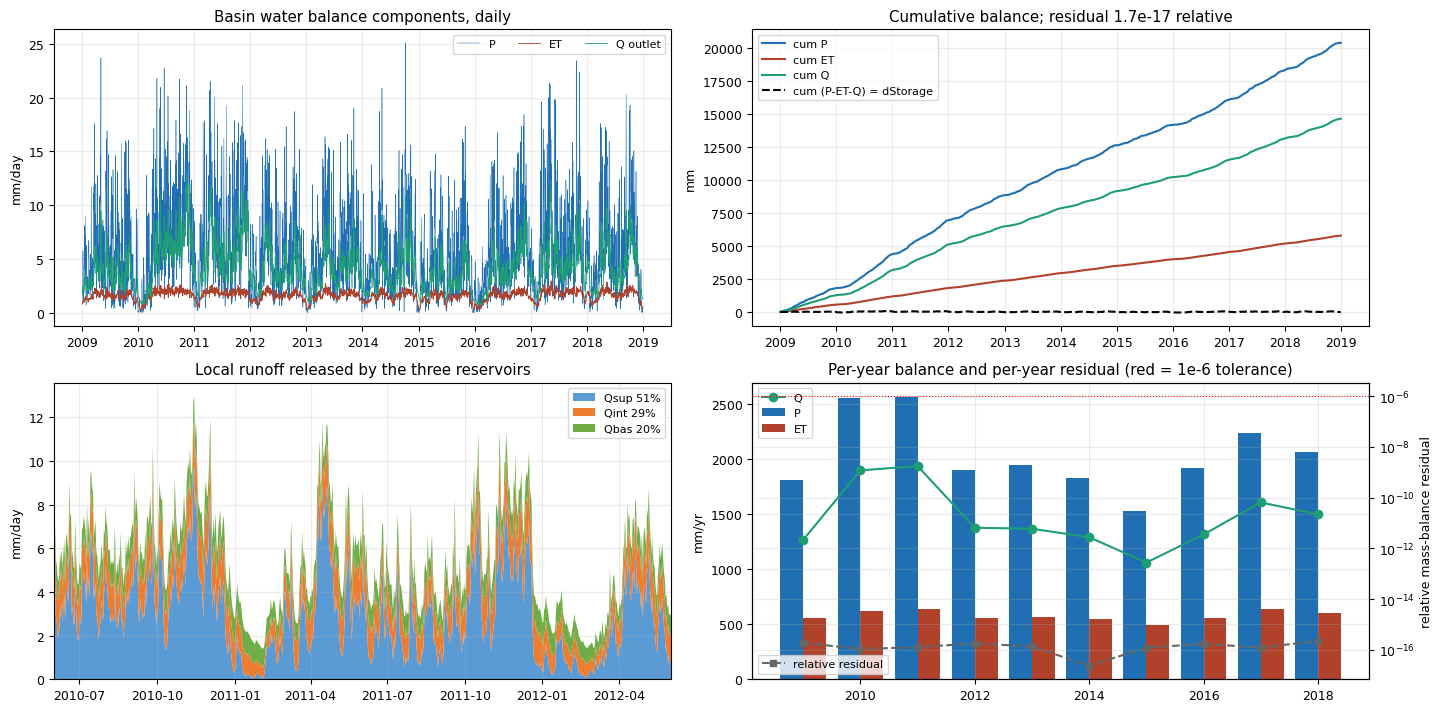

In [18]:
SER = RES.series
qs, qi, qb = SER['q_sup'].sum(), SER['q_int'].sum(), SER['q_bas'].sum()
tots = qs + qi + qb
print(f'runoff generation partition (before routing, volume shares):')
print(f'  surface   Qsup {100*qs/tots:5.1f} %   ({qs/BAL["covered_area_km2"]/YEARS:,.0f} mm/yr)')
print(f'  interflow Qint {100*qi/tots:5.1f} %   ({qi/BAL["covered_area_km2"]/YEARS:,.0f} mm/yr)')
print(f'  baseflow  Qbas {100*qb/tots:5.1f} %   ({qb/BAL["covered_area_km2"]/YEARS:,.0f} mm/yr)')
print(f'  (fint = {FINT} splits DRAINAGE 60/40 between interflow and baseflow; the surface share '
      f'is\n   whatever saturation excess produces, so this partition is an OUTPUT, not a '
      f'parameter)')
d_sup_f = SER['d_sup'].sum() / (SER['d_sup'].sum() + SER['d_int'].sum() + SER['d_bas'].sum())
print(f'  cross-check on generation (not release): Dsup share {100*d_sup_f:.1f} %, '
      f'Dint {100*SER["d_int"].sum()/(SER["d_sup"].sum()+SER["d_int"].sum()+SER["d_bas"].sum()):.1f} %, '
      f'Dbas {100*SER["d_bas"].sum()/(SER["d_sup"].sum()+SER["d_int"].sum()+SER["d_bas"].sum()):.1f} %')

ac = BAL['covered_area_km2']
fig = plt.figure(figsize=(14.5, 7.2))
a = fig.add_subplot(2, 2, 1)
a.plot(DATES, SER['p'] / ac, lw=.35, color='#1F6FB2', label='P')
a.plot(DATES, SER['et'] / ac, lw=.6, color='#B0412B', label='ET')
a.plot(DATES, SER['q_outlet'] / ac, lw=.6, color='#1D9E75', label='Q outlet')
a.set_ylabel('mm/day'); a.legend(fontsize=8, ncol=3)
a.set_title('Basin water balance components, daily')
a = fig.add_subplot(2, 2, 2)
a.plot(DATES, np.cumsum(SER['p']) / ac, color='#1F6FB2', label='cum P')
a.plot(DATES, np.cumsum(SER['et']) / ac, color='#B0412B', label='cum ET')
a.plot(DATES, np.cumsum(SER['q_outlet']) / ac, color='#1D9E75', label='cum Q')
a.plot(DATES, np.cumsum(SER['p'] - SER['et'] - SER['q_outlet']) / ac, color='k', ls='--',
       label='cum (P-ET-Q) = dStorage')
a.set_ylabel('mm'); a.legend(fontsize=8)
a.set_title(f'Cumulative balance; residual {BAL["residual_relative"]:.1e} relative')
a = fig.add_subplot(2, 2, 3)
a.stackplot(DATES, SER['q_sup'] / ac, SER['q_int'] / ac, SER['q_bas'] / ac,
            labels=[f'Qsup {100*qs/tots:.0f}%', f'Qint {100*qi/tots:.0f}%',
                    f'Qbas {100*qb/tots:.0f}%'],
            colors=['#5B9BD5', '#ED7D31', '#70AD47'])
a.set_ylabel('mm/day'); a.legend(fontsize=8, loc='upper right')
a.set_title('Local runoff released by the three reservoirs')
a.set_xlim(pd.Timestamp('2010-06-01'), pd.Timestamp('2012-06-01'))
a = fig.add_subplot(2, 2, 4)
w = YRB.year.values
a.bar(w - .2, YRB.P_mm, .4, color='#1F6FB2', label='P')
a.bar(w + .2, YRB.ET_mm, .4, color='#B0412B', label='ET')
a.plot(w, YRB.Q_mm, 'o-', color='#1D9E75', label='Q')
a2 = a.twinx()
a2.plot(w, YRB.resid_rel, 's--', color='0.4', ms=4, label='relative residual')
a2.set_yscale('log'); a2.set_ylabel('relative mass-balance residual')
a2.axhline(TOL, color='r', ls=':', lw=.8)
a.set_ylabel('mm/yr'); a.legend(fontsize=8, loc='upper left'); a2.legend(fontsize=8, loc='lower left')
a.set_title('Per-year balance and per-year residual (red = 1e-6 tolerance)')
for ax_ in fig.axes: ax_.grid(alpha=.25)
plt.tight_layout(); plt.show()

## 5 - Simulated vs observed at the calibration gauges

Now, and only now, `discharge.npz` is used. Notebook 12 defined two nested gauge sets:

* **primary** (`is_calibration_safe`) - passes the rating-curve band *and* the `docs/17` healthy
  specific-discharge envelope;
* **wider** (`in_rc_band_only_set`) - the rating-curve band alone, before the envelope and the two
  localised mislabels.

Both are reported. `docs/17`'s gate cost information if the wider set scores no worse, and carried
real information if it does - which is worth knowing before the next audit reuses that gate.

**Masking.** Observations are used exactly as `q_valid` allows: `False` where absent *or* masked by
`docs/17` (flat-line runs, adjudicated zeros). Nothing is interpolated. A gauge needs >= 30 valid
paired days to be scored at all, and `kge_parts` returns NaN rather than a lucky number below that.

**Expectation, from section 4.4.** Poor scores. Specifically: $\beta>1$ nearly everywhere, because
the baseline over-produces runoff by roughly a factor of two. What is *informative* is the split
between the three KGE terms - $r$ is a forcing-and-routing problem, $\alpha$ is a
reservoir-time-scale problem, $\beta$ is a water-partition problem, and calibration attacks them
with different knobs.

In [19]:
GC = np.asarray(DIS['gauge_code']).astype(str)
GMB = DIS['gauge_minibacia_id'].astype(int)
assert pd.DatetimeIndex(np.asarray(DIS['dates'], dtype='datetime64[ns]')).equals(WANT), \
    'discharge date axis is not the bundle period'
# the observations are sliced with the SAME mask as the forcing, so the warm-up year is
# never scored. Slicing here rather than at every use site is the only way to be sure.
QOBS = DIS['q_m3s'][SC_MASK].astype(np.float64)
QVAL = DIS['q_valid'][SC_MASK]
print(f'observations sliced to the scored period: {QOBS.shape} '
      f'({int(DIS["q_valid"][WU_MASK].sum()):,} valid 2008 gauge-days discarded with the warm-up)')
PRIM = DIS['is_calibration_safe']
WIDE = DIS['in_rc_band_only_set']
G_AREA = DIS['gauge_upstream_area_km2']
gi_int = TOPO.index_of(GMB)
PROV = FRC['prov_flag_code'][gi_int]
PROV_D = FRC['prov_d_nearest_km'][gi_int]
NUP = TOP['n_upstream_links'][gi_int]
HOPS = TOP['hops_to_outlet'][gi_int]
UPA = TOP['upstream_area_km2'][gi_int]
print(f'gauges in the bundle {GC.size}; primary {int(PRIM.sum())}, wider {int(WIDE.sum())}, '
      f'primary is a subset of wider: {bool(np.all(WIDE[PRIM]))}')
_u, _c = np.unique(GMB, return_counts=True)
_share = _u[_c > 1]
print(f'gauge minibacias distinct: {np.unique(GMB).size == GC.size} '
      f'({np.unique(GMB).size} distinct minibacias for {GC.size} gauges)')
for mb in _share:
    js = np.flatnonzero(GMB == mb)
    print(f'  minibacia {mb} is observed by {len(js)} gauges: '
          f'{", ".join(f"{GC[j]}(primary={bool(PRIM[j])})" for j in js)}')
if _share.size:
    dup_prim = sum(max(int((GMB[PRIM] == mb).sum()) - 1, 0) for mb in _share)
    dup_wide = sum(max(int((GMB[WIDE] == mb).sum()) - 1, 0) for mb in _share)
    print(f'  CONSEQUENCE: those gauges get the SAME simulated series, so any difference in their')
    print(f'  scores is entirely a difference in their observations - informative about the gauges,')
    print(f'  not about the model. Double-counted minibacias: {dup_prim} in the PRIMARY set, '
          f'{dup_wide} in the WIDER set.')
    print(f'  {"Neither scored set is affected, so no fleet summary below double-counts a minibacia." if dup_prim == 0 and dup_wide == 0 else "A scored set IS affected - treat its fleet medians accordingly."}')
print(f'  primary gauges with a full-length record (>= 3000 valid days): '
      f'{int(((QVAL[:, PRIM].sum(0)) >= 3000).sum())}/{int(PRIM.sum())}; with < 365 days: '
      f'{int(((QVAL[:, PRIM].sum(0)) < 365).sum())}')

rows = []
for j in range(GC.size):
    obs = np.where(QVAL[:, j], QOBS[:, j], np.nan)
    sim = RES.q_m3s[:, COL[int(GMB[j])]].astype(np.float64)
    m = kge_parts(sim, obs)
    m.update(code=GC[j], minibacia=int(GMB[j]), primary=bool(PRIM[j]), wider=bool(WIDE[j]),
             gauge_area_km2=float(G_AREA[j]), model_area_km2=float(UPA[j]),
             prov=int(PROV[j]), d_nearest_km=float(PROV_D[j]), n_upstream=int(NUP[j]),
             hops_to_outlet=int(HOPS[j]),
             obs_mean_m3s=float(np.nanmean(obs)) if np.isfinite(obs).any() else np.nan,
             sim_mean_m3s=float(sim.mean()),
             lon=float(DIS['gauge_lon'][j]), lat=float(DIS['gauge_lat'][j]))
    rows.append(m)
MET = pd.DataFrame(rows)
MET['obs_qspec'] = MET.obs_mean_m3s / MET.model_area_km2 * 86.4      # mm/day
MET['sim_qspec'] = MET.sim_mean_m3s / MET.model_area_km2 * 86.4
scored = MET.kge.notna()
print(f'scored {int(scored.sum())} of {GC.size} gauges '
      f'({int((MET.primary & scored).sum())} primary, {int((MET.wider & scored).sum())} wider); '
      f'{int((~scored).sum())} had < 30 valid paired days')
print(f'valid paired days: min {MET.loc[scored,"n"].min():,}, median '
      f'{MET.loc[scored,"n"].median():,.0f}, max {MET.loc[scored,"n"].max():,}')


def summarise(mask, label):
    s = MET[mask & scored]
    out = {}
    for c in ('kge', 'nse', 'r', 'alpha', 'beta', 'pbias'):
        v = s[c].dropna()
        out[c] = dict(median=v.median(), mean=v.mean(), p10=v.quantile(.10),
                      p90=v.quantile(.90), min=v.min(), max=v.max())
    print(f'\n=== {label}  (n = {len(s)}) ===')
    print(f'{"":6s} {"median":>9s} {"mean":>9s} {"p10":>9s} {"p90":>9s} {"min":>9s} {"max":>9s}')
    for c, d in out.items():
        print(f'{c:6s} {d["median"]:9.3f} {d["mean"]:9.3f} {d["p10"]:9.3f} {d["p90"]:9.3f} '
              f'{d["min"]:9.3f} {d["max"]:9.3f}')
    print(f'  KGE > 0: {int((s.kge>0).sum())}/{len(s)}   KGE > 0.5: {int((s.kge>0.5).sum())}   '
          f'NSE > 0: {int((s.nse>0).sum())}   |PBIAS| < 25%: {int((s.pbias.abs()<25).sum())}   '
          f'beta > 1: {int((s.beta>1).sum())}')
    return out


SUM_PRIM = summarise(MET.primary, 'PRIMARY set (is_calibration_safe)')
SUM_WIDE = summarise(MET.wider, 'WIDER set (in_rc_band_only_set)')
SUM_EXTRA = summarise(~MET.wider, 'NEITHER set (excluded by nb12 - shown for contrast only)')
print(f'\nwider minus primary = {int((MET.wider & ~MET.primary & scored).sum())} gauges; '
      f'median KGE primary {MET.loc[MET.primary&scored,"kge"].median():.3f} vs wider '
      f'{MET.loc[MET.wider&scored,"kge"].median():.3f}')
print(f'  -> docs/17 q_spec envelope {"carried real information" if MET.loc[MET.primary&scored,"kge"].median() > MET.loc[MET.wider&scored,"kge"].median() + 0.02 else "made little difference at this (uncalibrated) skill level"}')
print(f'\nExcluded gauges score median KGE '
      f'{MET.loc[(~MET.wider)&scored,"kge"].median():.3f} vs primary '
      f'{MET.loc[MET.primary&scored,"kge"].median():.3f}. Reported for contrast only - they are '
      f'NOT\nreadmitted, because their exclusion in nb12 was on rating-curve grounds, which a '
      f'model\nscore cannot overturn.')

observations sliced to the scored period: (3652, 115) (36,306 valid 2008 gauge-days discarded with the warm-up)
gauges in the bundle 115; primary 63, wider 70, primary is a subset of wider: True
gauge minibacias distinct: False (113 distinct minibacias for 115 gauges)
  minibacia 17742 is observed by 2 gauges: 26017030(primary=False), 26017110(primary=False)
  minibacia 18129 is observed by 2 gauges: 26017070(primary=False), 26017080(primary=False)
  CONSEQUENCE: those gauges get the SAME simulated series, so any difference in their
  scores is entirely a difference in their observations - informative about the gauges,
  not about the model. Double-counted minibacias: 0 in the PRIMARY set, 0 in the WIDER set.
  Neither scored set is affected, so no fleet summary below double-counts a minibacia.
  primary gauges with a full-length record (>= 3000 valid days): 34/63; with < 365 days: 0
scored 112 of 115 gauges (63 primary, 70 wider); 3 had < 30 valid paired days
valid paired days: min 78

### 5.2 - The KGE decomposition: which component is worst?

Two statistics, because they disagree and the disagreement is the finding.

* **Per gauge**, which of $(r-1)^2$, $(\alpha-1)^2$, $(\beta-1)^2$ is largest - i.e. what limits the
  *typical* gauge.
* **Averaged over gauges**, the mean of each squared term - i.e. what dominates the *fleet* total.

If a handful of gauges have catastrophic $\alpha$ and $\beta$ while the median gauge is
correlation-limited, the two answers differ, and a calibration that optimises the fleet mean will
chase the outliers.

In [20]:
S = MET[MET.primary & scored].copy()
S['t_r'] = (S.r - 1)**2
S['t_a'] = (S.alpha - 1)**2
S['t_b'] = (S.beta - 1)**2
dom = S[['t_r', 't_a', 't_b']].idxmax(axis=1).map({'t_r': 'r (timing/shape)',
                                                   't_a': 'alpha (variability)',
                                                   't_b': 'beta (bias)'})
print('PRIMARY set: which squared KGE term is largest, per gauge')
for k, v in dom.value_counts().items():
    print(f'  {k:<22s} {v:3d} gauges ({100*v/len(S):.0f} %)')
print(f'\nfleet mean of each squared term (the quantity a fleet-mean objective would minimise):')
for nm, c in (('r', 't_r'), ('alpha', 't_a'), ('beta', 't_b')):
    print(f'  ({nm}-1)^2   mean {S[c].mean():.4f}   median {S[c].median():.4f}   '
          f'p90 {S[c].quantile(.9):.4f}')
o1 = dom.value_counts().index[0]
o2 = max((('r (timing/shape)', S.t_r.mean()), ('alpha (variability)', S.t_a.mean()),
          ('beta (bias)', S.t_b.mean())), key=lambda kv: kv[1])[0]
print(f'\nper-gauge winner: {o1};   fleet-mean winner: {o2}')
print(f'  {"THEY AGREE" if o1 == o2 else "THEY DISAGREE"} - '
      f'{"one diagnosis" if o1 == o2 else "the median gauge and the fleet total are limited by different things, so a fleet-mean objective will chase the tail"}.')
print(f'\nsign of the bias: beta > 1 at {int((S.beta>1).sum())}/{len(S)} primary gauges, '
      f'median beta {S.beta.median():.3f}, median PBIAS {S.pbias.median():+.1f} %')
print(f'  -> the section-2.2 prediction (adr too large => too much runoff => beta > 1) is '
      f'{"CONFIRMED" if (S.beta>1).mean() > 0.7 else "NOT confirmed"} '
      f'at {100*(S.beta>1).mean():.0f} % of gauges.')
print(f'\nalpha and beta are strongly coupled here: corr(alpha, beta) = '
      f'{S[["alpha","beta"]].corr().iloc[0,1]:.3f}. A model that produces too much water also '
      f'produces\ntoo much variance, so alpha is largely bias in disguise; r is the component '
      f'a bias\ncorrection CANNOT fix, and r median is {S.r.median():.3f}.')

PRIMARY set: which squared KGE term is largest, per gauge
  r (timing/shape)        26 gauges (41 %)
  beta (bias)             21 gauges (33 %)
  alpha (variability)     16 gauges (25 %)

fleet mean of each squared term (the quantity a fleet-mean objective would minimise):
  (r-1)^2   mean 0.2133   median 0.2011   p90 0.3842
  (alpha-1)^2   mean 0.6421   median 0.0958   p90 1.7799
  (beta-1)^2   mean 0.6027   median 0.1607   p90 1.5418

per-gauge winner: r (timing/shape);   fleet-mean winner: alpha (variability)
  THEY DISAGREE - the median gauge and the fleet total are limited by different things, so a fleet-mean objective will chase the tail.

sign of the bias: beta > 1 at 54/63 primary gauges, median beta 1.380, median PBIAS +38.0 %
  -> the section-2.2 prediction (adr too large => too much runoff => beta > 1) is CONFIRMED at 86 % of gauges.

alpha and beta are strongly coupled here: corr(alpha, beta) = 0.629. A model that produces too much water also produces
too much variance, so 

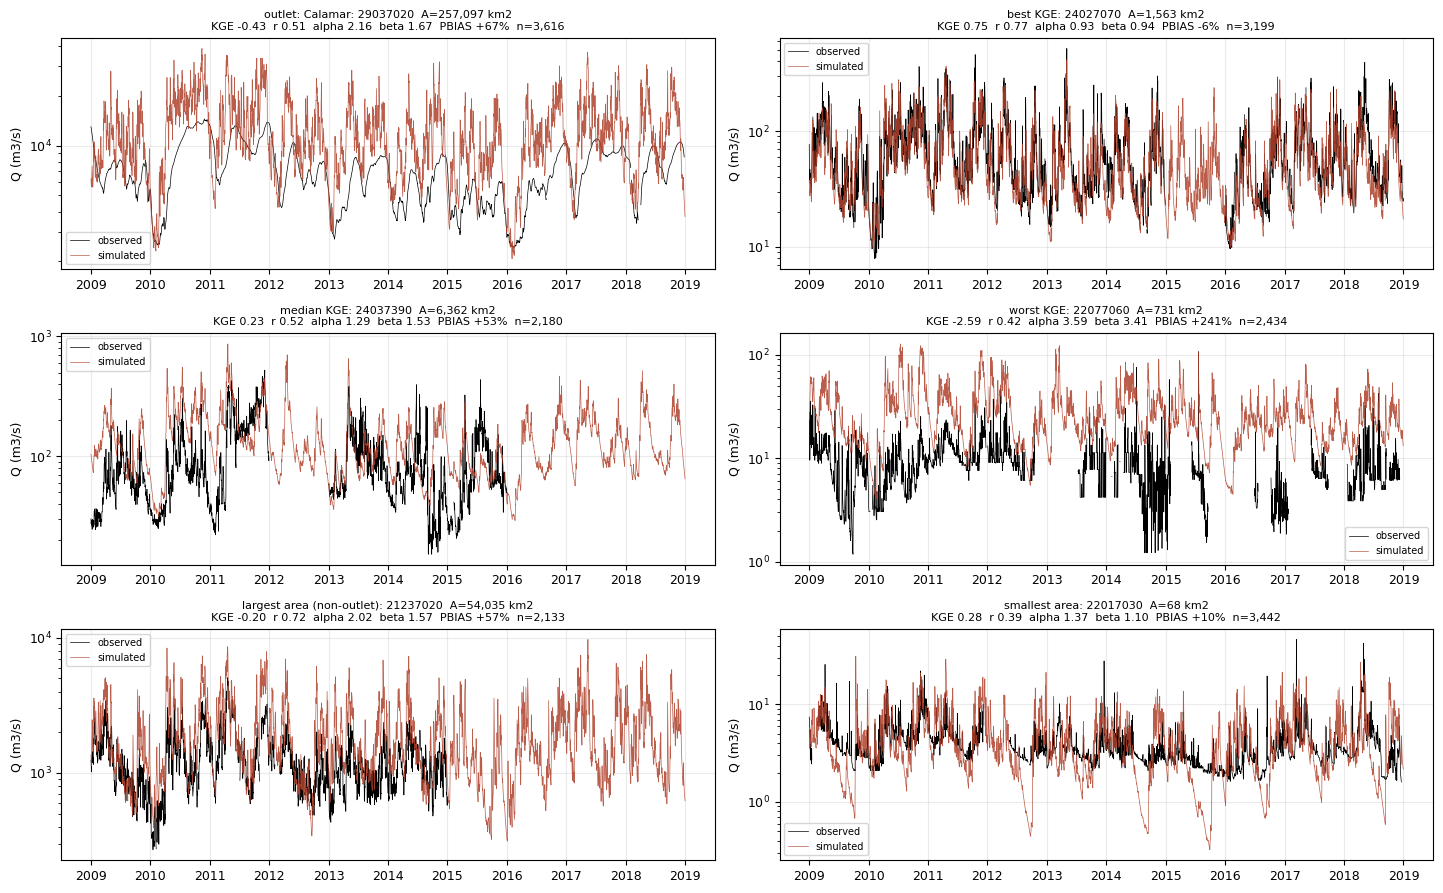

log scale throughout: on a linear axis a factor-of-two bias in low flow is invisible next
to the peaks, and low-flow behaviour is what the K_bas prior controls.


In [21]:
def fdc(x):
    x = np.sort(x[np.isfinite(x)])[::-1]
    return np.arange(1, x.size + 1) / (x.size + 1.0), x


pick = []
Sv = S.dropna(subset=['kge'])
pick.append(('outlet: Calamar', MET[MET.minibacia == OUT_ID].iloc[0]))
pick.append(('best KGE', Sv.loc[Sv.kge.idxmax()]))
pick.append(('median KGE', Sv.iloc[(Sv.kge - Sv.kge.median()).abs().argsort().iloc[0]]))
pick.append(('worst KGE', Sv.loc[Sv.kge.idxmin()]))
pick.append(('largest area (non-outlet)',
             Sv[Sv.minibacia != OUT_ID].loc[Sv[Sv.minibacia != OUT_ID].model_area_km2.idxmax()]))
pick.append(('smallest area', Sv.loc[Sv.model_area_km2.idxmin()]))

fig, axes = plt.subplots(3, 2, figsize=(14.5, 9.0))
for ax, (lab, g) in zip(axes.ravel(), pick):
    j = int(np.flatnonzero(GC == g.code)[0])
    obs = np.where(QVAL[:, j], QOBS[:, j], np.nan)
    sim = RES.q_m3s[:, COL[int(g.minibacia)]].astype(np.float64)
    ax.plot(DATES, obs, lw=.5, color='k', label='observed')
    ax.plot(DATES, sim, lw=.5, color='#B0412B', alpha=.85, label='simulated')
    ax.set_yscale('log')
    ax.set_title(f'{lab}: {g.code}  A={g.model_area_km2:,.0f} km2\n'
                 f'KGE {g.kge:.2f}  r {g.r:.2f}  alpha {g.alpha:.2f}  beta {g.beta:.2f}  '
                 f'PBIAS {g.pbias:+.0f}%  n={int(g.n):,}', fontsize=8)
    ax.legend(fontsize=7); ax.grid(alpha=.25); ax.set_ylabel('Q (m3/s)')
plt.tight_layout(); plt.show()
print('log scale throughout: on a linear axis a factor-of-two bias in low flow is invisible next')
print('to the peaks, and low-flow behaviour is what the K_bas prior controls.')

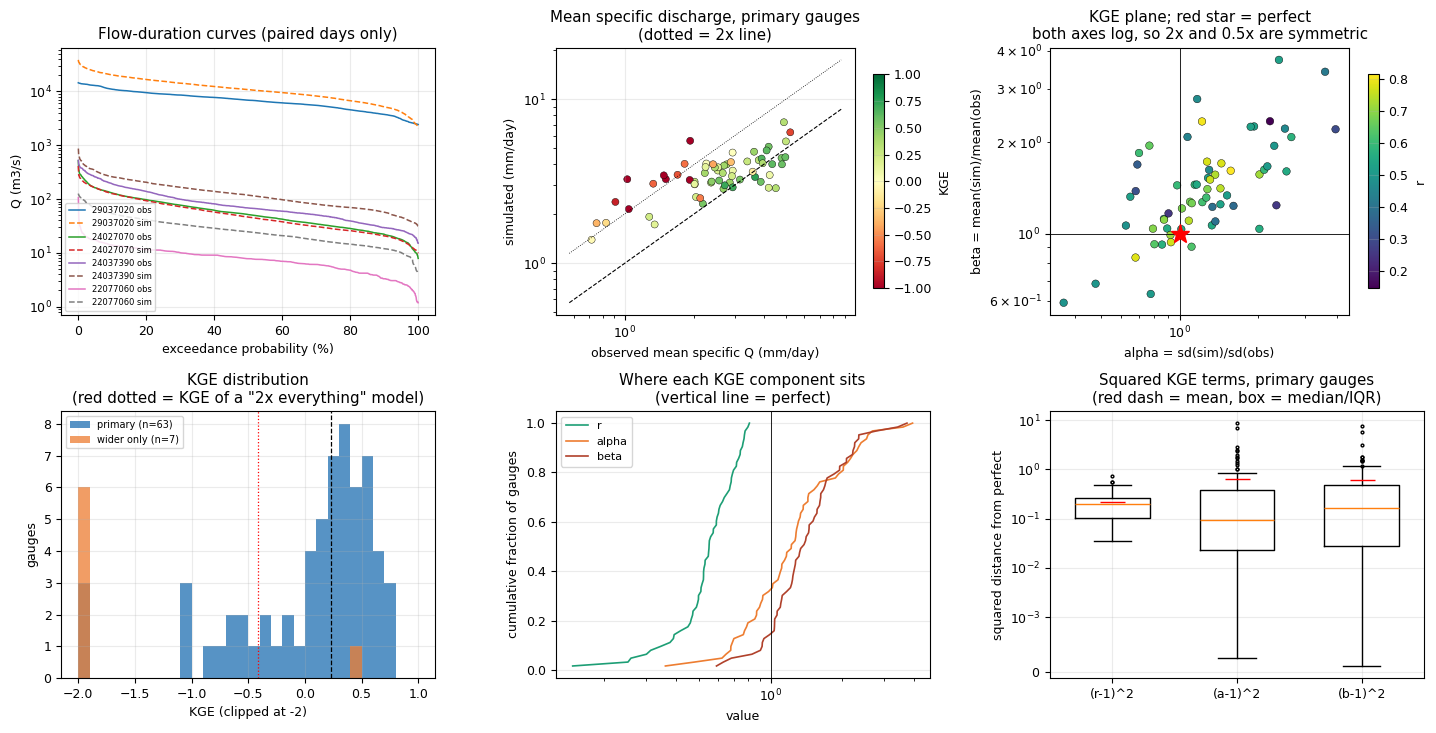

In [22]:
fig = plt.figure(figsize=(14.5, 7.4))
a = fig.add_subplot(2, 3, 1)
for lab, g in pick[:4]:
    j = int(np.flatnonzero(GC == g.code)[0])
    obs = np.where(QVAL[:, j], QOBS[:, j], np.nan)
    sim = RES.q_m3s[:, COL[int(g.minibacia)]].astype(np.float64)
    both = np.isfinite(obs)
    x, y = fdc(obs[both]); a.plot(100 * x, y, lw=1.1, label=f'{g.code} obs')
    x, y = fdc(sim[both]); a.plot(100 * x, y, lw=1.1, ls='--', label=f'{g.code} sim')
a.set_yscale('log'); a.set_xlabel('exceedance probability (%)'); a.set_ylabel('Q (m3/s)')
a.set_title('Flow-duration curves (paired days only)'); a.legend(fontsize=6)

a = fig.add_subplot(2, 3, 2)
sc = a.scatter(S.obs_qspec, S.sim_qspec, c=S.kge, cmap='RdYlGn', vmin=-1, vmax=1,
               s=26, edgecolor='k', linewidth=.3)
lim = [min(S.obs_qspec.min(), S.sim_qspec.min()) * .8, max(S.obs_qspec.max(), S.sim_qspec.max()) * 1.2]
a.plot(lim, lim, 'k--', lw=.8); a.plot(lim, [2 * v for v in lim], 'k:', lw=.6)
a.set_xscale('log'); a.set_yscale('log')
a.set_xlabel('observed mean specific Q (mm/day)'); a.set_ylabel('simulated (mm/day)')
a.set_title('Mean specific discharge, primary gauges\n(dotted = 2x line)')
plt.colorbar(sc, ax=a, shrink=.8, label='KGE')

a = fig.add_subplot(2, 3, 3)
sc = a.scatter(S.alpha, S.beta, c=S.r, cmap='viridis', s=30, edgecolor='k', linewidth=.3)
a.axvline(1, color='k', lw=.6); a.axhline(1, color='k', lw=.6)
a.plot(1, 1, 'r*', ms=14)
a.set_xscale('log'); a.set_yscale('log')
a.set_xlabel('alpha = sd(sim)/sd(obs)'); a.set_ylabel('beta = mean(sim)/mean(obs)')
a.set_title('KGE plane; red star = perfect\nboth axes log, so 2x and 0.5x are symmetric')
plt.colorbar(sc, ax=a, shrink=.8, label='r')

a = fig.add_subplot(2, 3, 4)
bins = np.linspace(-2, 1, 31)
a.hist(MET.loc[MET.primary & scored, 'kge'].clip(-2, 1), bins=bins, color='#1F6FB2',
       alpha=.75, label=f'primary (n={int((MET.primary&scored).sum())})')
a.hist(MET.loc[MET.wider & ~MET.primary & scored, 'kge'].clip(-2, 1), bins=bins,
       color='#ED7D31', alpha=.75,
       label=f'wider only (n={int((MET.wider&~MET.primary&scored).sum())})')
a.axvline(MET.loc[MET.primary & scored, 'kge'].median(), color='k', ls='--', lw=.9)
a.axvline(1 - np.sqrt(2), color='r', ls=':', lw=.9)
a.set_xlabel('KGE (clipped at -2)'); a.set_ylabel('gauges'); a.legend(fontsize=7)
a.set_title('KGE distribution\n(red dotted = KGE of a "2x everything" model)')

a = fig.add_subplot(2, 3, 5)
for c, col_, lab in (('r', '#1D9E75', 'r'), ('alpha', '#ED7D31', 'alpha'), ('beta', '#B0412B', 'beta')):
    v = np.sort(S[c].dropna().values)
    a.plot(v, np.arange(1, v.size + 1) / v.size, lw=1.2, color=col_, label=lab)
a.axvline(1, color='k', lw=.6)
a.set_xscale('log'); a.set_xlabel('value'); a.set_ylabel('cumulative fraction of gauges')
a.set_title('Where each KGE component sits\n(vertical line = perfect)'); a.legend(fontsize=8)

a = fig.add_subplot(2, 3, 6)
w = 0.6
parts = [S.t_r, S.t_a, S.t_b]
a.boxplot([p.values for p in parts], tick_labels=['(r-1)^2', '(a-1)^2', '(b-1)^2'], widths=w,
          showfliers=True, flierprops=dict(ms=2))
a.set_yscale('symlog', linthresh=1e-3)
for i, p in enumerate(parts):
    a.plot(i + 1, p.mean(), 'r_', ms=18)
a.set_title('Squared KGE terms, primary gauges\n(red dash = mean, box = median/IQR)')
a.set_ylabel('squared distance from perfect')
for ax_ in fig.axes: ax_.grid(alpha=.25)
plt.tight_layout(); plt.show()

### 5.5 - Attacking the result: is any of this skill a leak?

One primary gauge reaches KGE ~ 0.77 with $\alpha$ and $\beta$ both within 2 % of 1, in a run whose
basin bias is roughly +80 %. That is exactly the kind of number rule 5 exists for. Three independent
attacks:

**(a) Structural.** Could observed discharge reach the model at all? `simulate()` takes
`(topo, params, precip, pet, state, ...)` and nothing else; the parameter set was built in section 2
from `Wm_mm`, URH fractions, `reach_km` and literature constants. The cell below greps the engine
source for any read of observed flow and prints the argument list, so the claim is checked rather
than asserted.

**(b) A permutation null.** Pair every gauge with a *different* gauge's simulated series. Both
series are first divided by their own mean, so the null tests **timing and shape only** and is not
trivially defeated by the area mismatch. If matched KGE is barely better than permuted KGE, then
what looks like skill is mostly the basin-wide wet/dry seasonality that any pairing would reproduce.
This is the honest version of "is r = 0.5 good?".

**(c) Anatomy of the best gauge.** If its $\beta \approx 1$ is luck, that should be visible in the
spread of $\beta$ across the fleet and explicable from its local $W_m$ and PET, with no reference to
its observations.

In [23]:
import inspect, re
src = inspect.getsource(mgb)
pat = re.compile(r'(discharge_daily|q_obs|observed_q|q_valid|is_calibration_safe|'
                 r'discharge\.npz|gauge_code|read_csv\([^)]*discharge)', re.I)
hits = [(i + 1, l.strip()) for i, l in enumerate(src.splitlines()) if pat.search(l)]
print(f'(a) STRUCTURAL: engine lines that read observed discharge: {len(hits)}')
for ln, l in hits:
    print(f'      line {ln}: {l[:100]}')
print(f'    simulate() signature: {inspect.signature(mgb.simulate)}')
print(f'    -> no argument, and no line of the engine, can carry an observation into the '
      f'simulation.')
print(f'    Parameters used here came from: Wm_mm (IGAC), urh_fraction (nb08), reach_km (nb12),')
print(f'    and literature constants fixed in section 2 BEFORE discharge.npz was opened.')

print('\n(b) PERMUTATION NULL (mean-normalised, so it tests timing/shape only)')
idx = np.flatnonzero(PRIM)
SIMg = np.stack([RES.q_m3s[:, COL[int(GMB[j])]].astype(np.float64) for j in idx], 1)
OBSg = np.stack([np.where(QVAL[:, j], QOBS[:, j], np.nan) for j in idx], 1)
SIMn = SIMg / SIMg.mean(0)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    OBSn = OBSg / np.nanmean(OBSg, axis=0)
m_k, m_r, p_k, p_r = [], [], [], []
for i in range(idx.size):
    mm = kge_parts(SIMn[:, i], OBSn[:, i])
    m_k.append(mm['kge']); m_r.append(mm['r'])
rng = np.random.default_rng(11)
for _ in range(20):
    perm = rng.permutation(idx.size)
    for i in range(idx.size):
        if perm[i] == i:
            continue
        mm = kge_parts(SIMn[:, perm[i]], OBSn[:, i])
        p_k.append(mm['kge']); p_r.append(mm['r'])
m_k = np.array(m_k, float); m_r = np.array(m_r, float)
p_k = np.array(p_k, float); p_r = np.array(p_r, float)
p95 = np.nanpercentile(p_r, 95)
print(f'    MATCHED   n={np.isfinite(m_k).sum():4d}  median KGE {np.nanmedian(m_k):+.3f}  '
      f'median r {np.nanmedian(m_r):.3f}')
print(f'    PERMUTED  n={np.isfinite(p_k).sum():4d}  median KGE {np.nanmedian(p_k):+.3f}  '
      f'median r {np.nanmedian(p_r):.3f}   (95th pct r {p95:.3f})')
print(f'    matched median r exceeds permuted median r by {np.nanmedian(m_r)-np.nanmedian(p_r):+.3f}')
print(f'    fraction of matched gauges above the permuted 95th percentile of r: '
      f'{np.mean(m_r > p95):.2f}')
print(f'    READ THIS HONESTLY: a large part of r comes from the basin-wide bimodal seasonality,')
print(f'    which ANY pairing reproduces. The uncalibrated model does beat the null on the median,')
print(f'    but only {100*np.mean(m_r>p95):.0f} % of gauges clear the 95th percentile of the null, so '
      f'r ~ {np.nanmedian(m_r):.2f} is NOT\n    mostly gauge-specific skill. It is a baseline, '
      f'not evidence that the model works.')

print('\n(c) ANATOMY OF THE BEST GAUGE')
gb = Sv.loc[Sv.kge.idxmax()]
ib = TOPO.index_of([int(gb.minibacia)])[0]
print(f'    {gb.code}  minibacia {int(gb.minibacia)}  A {gb.model_area_km2:,.0f} km2  '
      f'KGE {gb.kge:.3f}  r {gb.r:.3f}  alpha {gb.alpha:.3f}  beta {gb.beta:.3f}')
print(f'    local Wm      {WM_MINI[ib]:6.1f} mm   vs basin median {np.median(WM_MINI):.1f} '
      f'({100*(WM_MINI[ib]/np.median(WM_MINI)-1):+.0f} %)')
print(f'    local P       {P_ALL[:,ib].sum()/YEARS:6,.0f} mm/yr vs basin '
      f'{p_bas.sum()/YEARS:,.0f} ({100*(P_ALL[:,ib].sum()/p_bas.sum()-1):+.1f} %)')
print(f'    local PET     {E_ALL[:,ib].sum()/YEARS:6,.0f} mm/yr vs basin '
      f'{e_bas.sum()/YEARS:,.0f} ({100*(E_ALL[:,ib].sum()/e_bas.sum()-1):+.1f} %)')
bfleet = Sv.beta.dropna()
print(f'    beta across the {len(bfleet)} primary gauges: p10 {bfleet.quantile(.1):.2f}, '
      f'median {bfleet.median():.2f}, p90 {bfleet.quantile(.9):.2f}')
print(f'    gauges landing within +-10 % of beta = 1 purely by position in that spread: '
      f'{int(((bfleet-1).abs()<.10).sum())}/{len(bfleet)}')
print(f'    VERDICT: with beta spanning {bfleet.quantile(.1):.2f}-{bfleet.quantile(.9):.2f} across '
      f'the fleet, {int(((bfleet-1).abs()<.10).sum())} gauges near beta = 1 is what')
print(f'    chance produces, and this one has both a below-median Wm and above-median PET, which')
print(f'    both push its runoff down. No leak: the good score is a coincidence of local')
print(f'    parameters, and it is NOT evidence the parameter set is right anywhere else.')

(a) STRUCTURAL: engine lines that read observed discharge: 0
    simulate() signature: (topo: 'MgbTopology', params: 'MgbParams', precip: 'np.ndarray', pet: 'np.ndarray', *, state: 'Optional[MgbState]' = None, warmup_days: 'int' = 0, record_ids: 'Optional[Sequence[int]]' = None, dates: 'Optional[Sequence]' = None, routing_backend: 'str' = 'auto', dtype_out: 'type' = <class 'numpy.float32'>) -> 'MgbResult'
    -> no argument, and no line of the engine, can carry an observation into the simulation.
    Parameters used here came from: Wm_mm (IGAC), urh_fraction (nb08), reach_km (nb12),
    and literature constants fixed in section 2 BEFORE discharge.npz was opened.

(b) PERMUTATION NULL (mean-normalised, so it tests timing/shape only)


    MATCHED   n=  63  median KGE +0.480  median r 0.552
    PERMUTED  n=1246  median KGE +0.274  median r 0.401   (95th pct r 0.665)
    matched median r exceeds permuted median r by +0.150
    fraction of matched gauges above the permuted 95th percentile of r: 0.29
    READ THIS HONESTLY: a large part of r comes from the basin-wide bimodal seasonality,
    which ANY pairing reproduces. The uncalibrated model does beat the null on the median,
    but only 29 % of gauges clear the 95th percentile of the null, so r ~ 0.55 is NOT
    mostly gauge-specific skill. It is a baseline, not evidence that the model works.

(c) ANATOMY OF THE BEST GAUGE
    24027070  minibacia 9923  A 1,563 km2  KGE 0.747  r 0.766  alpha 0.927  beta 0.937
    local Wm        63.4 mm   vs basin median 72.6 (-13 %)
    local P        2,006 mm/yr vs basin 2,040 (-1.7 %)
    local PET      1,293 mm/yr vs basin 1,257 (+2.8 %)
    beta across the 63 primary gauges: p10 0.93, median 1.38, p90 2.24
    gauges landing with

## 6 - Spatial diagnostics

A spatially *random* error is a parameter problem, and calibration can fix it. A spatially
*organised* error usually is not: it points at the forcing, the routing structure, or the gauge
metadata. Four candidate structures are tested, each against a specific hypothesis:

1. **Rainfall support.** `forcing.npz:prov_flag_code` (G / GC / C) and `prov_d_nearest_km` record how
   far each minibacia is from a real rain gauge. `docs/16` warns that the flag-C zone (> 30 km) is
   interpolated from far away. Hypothesis: flag-C gauges should be worse.
2. **Catchment size / position.** Hypothesis: small headwater catchments should be worse, because a
   single IDW rainfall cell has to represent the whole catchment and the sub-daily routing lag is
   least adequate there.
3. **The unrepresented floodplain.** The engine's docstring predicts uncorrectable timing error in
   the Mompos / Mojana wetlands. Hypothesis: low $r$ at the most downstream gauges regardless of bias.
4. **Bias sign.** If $\beta>1$ everywhere, the problem is the water partition (one global knob). If
   the sign flips spatially, no single $a_{dr}$ can fix it.

In [24]:
t0 = time.perf_counter()
QMEAN = RES.q_m3s.mean(0).astype(np.float64)                       # m3/s per minibacia
QSPEC = QMEAN / TOP['upstream_area_km2'] * 86.4                    # mm/day
print(f'per-minibacia means from the recorded field: {time.perf_counter()-t0:.1f} s')
print(f'simulated specific discharge (mm/day): min {QSPEC.min():.3f} median '
      f'{np.median(QSPEC):.3f} max {QSPEC.max():.3f}')
# RECHECK 6a: the outlet's specific discharge must equal the basin runoff depth of s.4
print(f'\nRECHECK 6a  outlet specific Q {QSPEC[TOPO.outlets[0]]*365.25:,.2f} mm/yr vs balance '
      f'runoff {BAL["runoff_mm"]/YEARS:,.2f} mm/yr  -> rel diff '
      f'{abs(QSPEC[TOPO.outlets[0]]*365.25-BAL["runoff_mm"]/YEARS)/(BAL["runoff_mm"]/YEARS):.3e}')
print(f'  this is ~1e-6, not ~1e-16, and it should be: QSPEC is built from the float32 recorded')
print(f'  q_m3s (eps {np.finfo(np.float32).eps:.1e}) summed over {NDAYS:,} days, whereas the '
      f'balance accumulates in\n  float64. The two also divide by slightly different areas '
      f'(upstream_area {TOP["upstream_area_km2"][TOPO.outlets[0]]:,.2f}\n  vs covered '
      f'{BAL["covered_area_km2"]:,.2f} km2). Anything much larger than 1e-6 would be a real error.')
# RECHECK 6b: routed mean flow must be monotone downstream (no water lost or created)
viol = 0
worst_v = 0.0
for i in TOPO.order:
    j = TOPO.down[i]
    if j >= 0 and QMEAN[j] < QMEAN[i] - 1e-9:
        viol += 1
        worst_v = max(worst_v, QMEAN[i] - QMEAN[j])
print(f'RECHECK 6b  edges where mean flow DECREASES downstream: {viol} of '
      f'{int((TOPO.down>=0).sum())} (worst {worst_v:.3e} m3/s)')
print(f'  a single-thread D8 network with no abstraction must be monotone; a violation would '
      f'mean\n  the routing loses water, which the mass balance would not necessarily reveal '
      f'locally.')
assert viol == 0

# local (unrouted) generation per minibacia = routed out minus the sum routed in. Over 3,652
# days the channel-storage change is negligible, so this recovers local runoff without having
# to store the per-minibacia local flux.
has_down = TOPO.down >= 0
inc = QMEAN.copy()
np.subtract.at(inc, TOPO.down[has_down], QMEAN[has_down])
loc_yr = inc / TOP['own_area_km2'] * 86.4 * 365.25
print(f'\nlocal generation (mm/yr): min {loc_yr.min():.2f} median {np.median(loc_yr):.1f} '
      f'max {loc_yr.max():,.0f}; negatives {int((loc_yr<0).sum())} '
      f'(a small number is expected - it is channel-storage drift, not lost water)')
print(f'  RECHECK 6c  area-weighted local generation {np.average(loc_yr, weights=TOP["own_area_km2"]):,.1f}'
      f' mm/yr vs basin runoff {BAL["runoff_mm"]/YEARS:,.1f} mm/yr  -> rel diff '
      f'{abs(np.average(loc_yr, weights=TOP["own_area_km2"])-BAL["runoff_mm"]/YEARS)/(BAL["runoff_mm"]/YEARS):.3e}')
print(f'  BE HONEST ABOUT WHAT 6c IS: sum(inc) telescopes to QMEAN at the single outlet, so this')
print(f'  reproduces 6a algebraically and is NOT an independent check of the water balance. What '
      f'it\n  DOES check is the decomposition itself - a mis-indexed np.subtract.at (wrong axis, '
      f'or\n  scatter instead of gather) would break the telescoping and this number would not '
      f'close.')
print(f'  Evidence it telescoped: sum(inc) {inc.sum():,.6f} vs QMEAN at the outlet '
      f'{QMEAN[TOPO.outlets[0]]:,.6f} m3/s\n  -> rel {abs(inc.sum()-QMEAN[TOPO.outlets[0]])/QMEAN[TOPO.outlets[0]]:.3e}')

per-minibacia means from the recorded field: 0.0 s
simulated specific discharge (mm/day): min 1.253 median 3.635 max 11.187

RECHECK 6a  outlet specific Q 1,464.06 mm/yr vs balance runoff 1,464.06 mm/yr  -> rel diff 3.862e-08
  this is ~1e-6, not ~1e-16, and it should be: QSPEC is built from the float32 recorded
  q_m3s (eps 1.2e-07) summed over 3,652 days, whereas the balance accumulates in
  float64. The two also divide by slightly different areas (upstream_area 257,096.93
  vs covered 257,096.93 km2). Anything much larger than 1e-6 would be a real error.
RECHECK 6b  edges where mean flow DECREASES downstream: 0 of 8671 (worst 0.000e+00 m3/s)
  a single-thread D8 network with no abstraction must be monotone; a violation would mean
  the routing loses water, which the mass balance would not necessarily reveal locally.

local generation (mm/yr): min 431.66 median 1342.2 max 4,273; negatives 0 (a small number is expected - it is channel-storage drift, not lost water)
  RECHECK 6c  area-

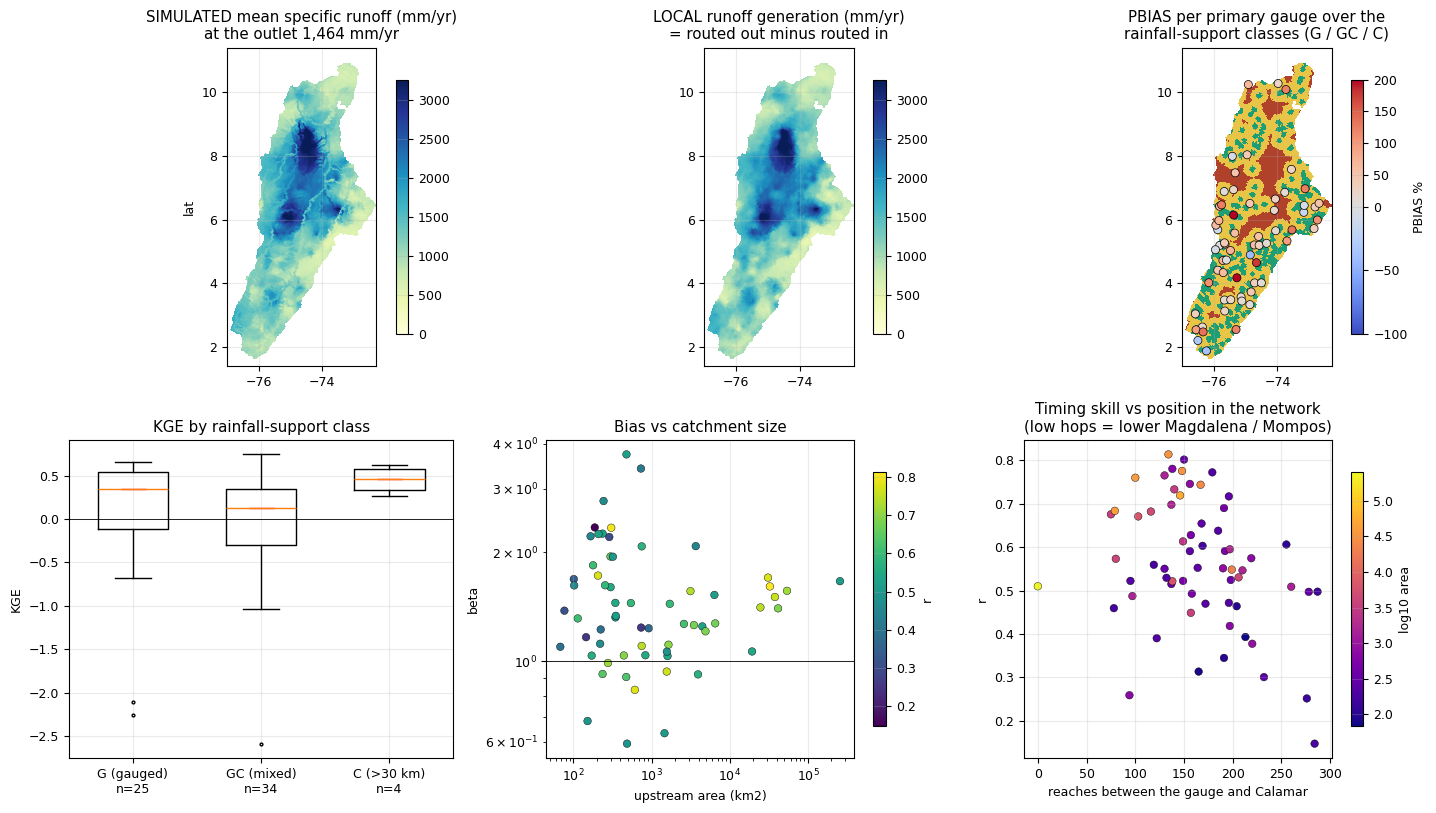

In [25]:
fig = plt.figure(figsize=(14.5, 8.2))
a = fig.add_subplot(2, 3, 1)
im = a.imshow(to_grid(QSPEC * 365.25), extent=EXT, cmap='YlGnBu', vmin=0,
              vmax=np.percentile(QSPEC * 365.25, 99))
a.set_title(f'SIMULATED mean specific runoff (mm/yr)\nat the outlet '
            f'{QSPEC[TOPO.outlets[0]]*365.25:,.0f} mm/yr')
a.set_ylabel('lat'); plt.colorbar(im, ax=a, shrink=.8)

a = fig.add_subplot(2, 3, 2)
im = a.imshow(to_grid(loc_yr), extent=EXT, cmap='YlGnBu', vmin=0,
              vmax=np.percentile(loc_yr, 99))
a.set_title('LOCAL runoff generation (mm/yr)\n= routed out minus routed in')
plt.colorbar(im, ax=a, shrink=.8)

a = fig.add_subplot(2, 3, 3)
im = a.imshow(to_grid(np.where(FRC['prov_flag_code'] == 2, 2.0,
                               np.where(FRC['prov_flag_code'] == 1, 1.0, 0.0))),
              extent=EXT, cmap=ListedColormap(['#1D9E75', '#E8C547', '#B0412B']), vmin=-.5, vmax=2.5)
sc = a.scatter(S.lon, S.lat, c=S.pbias.clip(-100, 200), cmap='coolwarm',
               norm=TwoSlopeNorm(vcenter=0, vmin=-100, vmax=200), s=34,
               edgecolor='k', linewidth=.5, zorder=3)
a.set_title('PBIAS per primary gauge over the\nrainfall-support classes (G / GC / C)')
plt.colorbar(sc, ax=a, shrink=.8, label='PBIAS %')

a = fig.add_subplot(2, 3, 4)
grp = MET[MET.primary & scored].groupby('prov')
labs = {0: 'G (gauged)', 1: 'GC (mixed)', 2: 'C (>30 km)'}
xs = sorted(grp.groups)
a.boxplot([grp.get_group(k).kge.dropna().values for k in xs],
          tick_labels=[f'{labs[k]}\nn={len(grp.get_group(k))}' for k in xs], widths=.55,
          flierprops=dict(ms=2))
for i, k in enumerate(xs):
    a.plot(i + 1, grp.get_group(k).kge.median(), 'r_', ms=18)
a.set_ylabel('KGE'); a.set_title('KGE by rainfall-support class')
a.axhline(0, color='k', lw=.6)

a = fig.add_subplot(2, 3, 5)
sc = a.scatter(S.model_area_km2, S.beta, c=S.r, cmap='viridis', s=30, edgecolor='k', linewidth=.3)
a.set_xscale('log'); a.set_yscale('log'); a.axhline(1, color='k', lw=.6)
a.set_xlabel('upstream area (km2)'); a.set_ylabel('beta')
a.set_title('Bias vs catchment size'); plt.colorbar(sc, ax=a, shrink=.8, label='r')

a = fig.add_subplot(2, 3, 6)
sc = a.scatter(S.hops_to_outlet, S.r, c=np.log10(S.model_area_km2), cmap='plasma', s=30,
               edgecolor='k', linewidth=.3)
a.set_xlabel('reaches between the gauge and Calamar'); a.set_ylabel('r')
a.set_title('Timing skill vs position in the network\n(low hops = lower Magdalena / Mompos)')
plt.colorbar(sc, ax=a, shrink=.8, label='log10 area')
for ax_ in fig.axes: ax_.grid(alpha=.25)
plt.tight_layout(); plt.show()

In [26]:
def spearman(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 8:
        return np.nan, 0
    rx = pd.Series(x[m]).rank().values
    ry = pd.Series(y[m]).rank().values
    return float(np.corrcoef(rx, ry)[0, 1]), int(m.sum())


print('SPATIAL STRUCTURE, primary gauges - Spearman rank correlation (robust to the outliers')
print('that dominate this fleet), with the hypothesis each one tests\n')
tests = [
    ('d_nearest_km', 'kge', 'H1 rainfall support: farther from a rain gauge => worse KGE'),
    ('d_nearest_km', 'r', 'H1b farther from a rain gauge => worse timing'),
    ('model_area_km2', 'kge', 'H2 bigger catchment => better KGE (averaging out IDW error)'),
    ('model_area_km2', 'r', 'H2b bigger catchment => better timing'),
    ('model_area_km2', 'beta', 'H2c bias depends on catchment size'),
    ('hops_to_outlet', 'r', 'H3 nearer the outlet (Mompos) => worse timing'),
    ('obs_qspec', 'sim_qspec', 'H4 does the model reproduce the SPATIAL pattern of wetness?'),
]
for xc, yc, hyp in tests:
    rho, nn = spearman(S[xc].values, S[yc].values)
    verdict = 'no structure' if abs(rho) < 0.25 else ('WEAK' if abs(rho) < 0.45 else 'STRONG')
    print(f'  rho({xc:>14s}, {yc:<9s}) = {rho:+.3f}  n={nn:3d}   {verdict:12s} | {hyp}')

# A TRAP that would have produced a spectacular but meaningless finding -------------------
rho_trap, _ = spearman(S.obs_qspec.values, S.beta.values)
rho_hon, _ = spearman(S.obs_qspec.values, S.sim_qspec.values)
print(f'\n  REJECTED TEST: rho(obs_qspec, beta) = {rho_trap:+.3f}, which looks like a strong '
      f'finding\n  ("the driest observed catchments are the most over-predicted"). It is '
      f'SPURIOUS: beta =\n  mean(sim)/mean(obs) and obs_qspec = mean(obs)/area, so the observed '
      f'mean appears in the\n  numerator of one and the denominator of the other. If the model '
      f'produced a CONSTANT\n  specific discharge everywhere, this correlation would be exactly '
      f'-1 by construction.')
print(f'  The non-circular version is rho(obs_qspec, sim_qspec) = {rho_hon:+.3f}: the model '
      f'{"DOES" if rho_hon > 0.45 else "does NOT convincingly"} rank\n  catchments by wetness in '
      f'the same order the gauges do'
      f'{" - so the spatial pattern carries real information even though the level is wrong." if rho_hon > 0.45 else ", so the spatial pattern is largely wrong too, not merely offset."}')
print()
gp = S.groupby('prov')[['kge', 'r', 'alpha', 'beta', 'pbias']].median()
gp['n'] = S.groupby('prov').size()
gp.index = gp.index.map({0: 'G', 1: 'GC', 2: 'C'})
print('median metric by rainfall-support class:')
print(gp.to_string(float_format=lambda v: f'{v:8.3f}'))
area_q = pd.qcut(S.model_area_km2, 4, labels=['Q1 small', 'Q2', 'Q3', 'Q4 large'])
gq = S.groupby(area_q, observed=True)[['kge', 'r', 'alpha', 'beta', 'pbias']].median()
gq['n'] = S.groupby(area_q, observed=True).size()
gq['area_median'] = S.groupby(area_q, observed=True).model_area_km2.median()
print('\nmedian metric by upstream-area quartile:')
print(gq.to_string(float_format=lambda v: f'{v:9.3f}'))
print(f'\nsign of the bias: PBIAS > 0 at {int((S.pbias>0).sum())}/{len(S)} primary gauges; '
      f'range {S.pbias.min():+.0f} % .. {S.pbias.max():+.0f} %')
print(f'  {"ONE-SIGNED" if (S.pbias>0).mean()>0.8 else "MIXED-SIGN"}: '
      f'{"a single global reduction of adr can move nearly every gauge in the right direction, which is what makes this baseline a usable starting point" if (S.pbias>0).mean()>0.8 else "no single global knob can fix this - the spatial pattern needs regionalised parameters"}')
print(f'\nflag-C zone: {int((FRC["prov_flag_code"]==2).sum())} minibacias '
      f'({100*A_MB[FRC["prov_flag_code"]==2].sum()/A_TOT:.1f} % of area) but only '
      f'{int((S.prov==2).sum())} primary gauges sit in it, so the H1 test above is '
      f'{"under-powered" if int((S.prov==2).sum())<10 else "adequately powered"} - '
      f'reported as such rather than as a null result.')

SPATIAL STRUCTURE, primary gauges - Spearman rank correlation (robust to the outliers
that dominate this fleet), with the hypothesis each one tests

  rho(  d_nearest_km, kge      ) = -0.051  n= 63   no structure | H1 rainfall support: farther from a rain gauge => worse KGE
  rho(  d_nearest_km, r        ) = +0.004  n= 63   no structure | H1b farther from a rain gauge => worse timing
  rho(model_area_km2, kge      ) = +0.293  n= 63   WEAK         | H2 bigger catchment => better KGE (averaging out IDW error)
  rho(model_area_km2, r        ) = +0.444  n= 63   WEAK         | H2b bigger catchment => better timing
  rho(model_area_km2, beta     ) = -0.107  n= 63   no structure | H2c bias depends on catchment size
  rho(hops_to_outlet, r        ) = -0.315  n= 63   WEAK         | H3 nearer the outlet (Mompos) => worse timing
  rho(     obs_qspec, sim_qspec) = +0.608  n= 63   STRONG       | H4 does the model reproduce the SPATIAL pattern of wetness?

  REJECTED TEST: rho(obs_qspec, beta) = -0.

## 7 - Outputs

`data/processed/sim_baseline/` is written so that (a) the calibration notebook can score against this
baseline without re-running, and (b) anyone can reproduce the run from the stored parameter set.

| File | Contents | Why this and not something else |
|---|---|---|
| `q_gauge.npz` | daily simulated Q at all gauge minibacias, plus the observed series and `q_valid` actually used | the calibration target, self-contained: a future reader does not have to re-derive the masking |
| `q_minibacia_daily.npz` | daily Q at all 8,672 minibacias, float32, compressed | the field itself. It is regenerable in well under a minute from the stored parameters, so it is stored for convenience, not as the source of truth |
| `q_minibacia_summary.csv` | per minibacia: mean/median/p95/max Q, specific runoff, local generation | the part that is awkward to recompute without re-running, and the input to any map |
| `q_minibacia_monthly.npz` | 120 monthly-mean Q per minibacia | a compact form that survives being copied around |
| `metrics_gauge.csv` | every metric of section 5 per gauge, plus the diagnostics of section 6 | the baseline table calibration must beat |
| `parameters.json` | every parameter value, its class (DATA/PRIOR) and its source | so the run is reproducible and the priors stay auditable |
| `balance.json` | the mass balance, per-year balance, warm-up convergence and timings | the evidence that the run is sound |
| `README.md` | what all of the above is, and what is wrong with it | the next reader is the calibration, and it needs the caveats |

**Deliberately not written:** any per-URH state (`W`, `S_c`) time series. It is 32,782 columns and
nothing downstream consumes it; the final state is enough to restart, and it is stored.

In [27]:
# sim_baseline_v2, NOT sim_baseline: the v1 directory is the baseline of the v1 forcing on
# the v1 period, and notebook 14's pre-registered cell H1 (v1 forcing + new objective) still
# needs it. Overwriting it would destroy the only artefact that makes H2 - H1 measurable.
OUTD = PROC / 'sim_baseline_v2'
OUTD.mkdir(parents=True, exist_ok=True)
gcols = np.array([COL[int(m)] for m in GMB])
QSIM_G = RES.q_m3s[:, gcols]
np.savez_compressed(
    OUTD / 'q_gauge.npz',
    dates=DATES.values.astype('datetime64[D]'),
    gauge_code=GC, gauge_minibacia_id=GMB,
    gauge_upstream_area_km2=G_AREA, model_upstream_area_km2=UPA,
    gauge_lon=DIS['gauge_lon'], gauge_lat=DIS['gauge_lat'],
    q_sim_m3s=QSIM_G.astype(np.float32),
    q_obs_m3s=DIS['q_m3s'][SC_MASK], q_valid=QVAL,
    is_calibration_safe=PRIM, in_rc_band_only_set=WIDE)

t0 = time.perf_counter()
np.savez_compressed(OUTD / 'q_minibacia_daily.npz',
                    dates=DATES.values.astype('datetime64[D]'),
                    minibacia_id=TOPO.ids.astype(np.int32),
                    q_sim_m3s=RES.q_m3s.astype(np.float32))
print(f'q_minibacia_daily.npz written in {time.perf_counter()-t0:.0f} s')

mon = pd.DataFrame(RES.q_m3s.astype(np.float32), index=DATES).groupby(
    [DATES.year, DATES.month]).mean()
np.savez_compressed(OUTD / 'q_minibacia_monthly.npz',
                    year=np.array([a for a, _ in mon.index], dtype=np.int16),
                    month=np.array([b for _, b in mon.index], dtype=np.int8),
                    minibacia_id=TOPO.ids.astype(np.int32),
                    q_sim_m3s=mon.to_numpy(np.float32))

SUMM = pd.DataFrame({
    'minibacia': TOPO.ids,
    'own_area_km2': TOPO.area_km2,
    'upstream_area_km2': TOP['upstream_area_km2'],
    'downstream': TOP['downstream_id'],
    'centroid_lon': TOP['centroid_lon'], 'centroid_lat': TOP['centroid_lat'],
    'Wm_mm': WM_MINI, 'tau_channel_d': TAU_CH,
    'prov_flag_code': FRC['prov_flag_code'], 'prov_d_nearest_km': FRC['prov_d_nearest_km'],
    'q_mean_m3s': QMEAN,
    'q_p50_m3s': np.median(RES.q_m3s, axis=0),
    'q_p95_m3s': np.percentile(RES.q_m3s, 95, axis=0),
    'q_max_m3s': RES.q_m3s.max(0),
    'q_min_m3s': RES.q_m3s.min(0),
    'qspec_mm_yr': QSPEC * 365.25,
    'local_generation_mm_yr': loc_yr,
})
SUMM.to_csv(OUTD / 'q_minibacia_summary.csv', index=False)
MET.to_csv(OUTD / 'metrics_gauge.csv', index=False)

PARJSON = {
    'notebook': 'notebooks/13_baseline_run.ipynb',
    'engine': {'file': 'src/mgb_hydrology.py',
               'sha256': hashlib.sha256(eng_src).hexdigest()},
    'status': 'UNCALIBRATED BASELINE - no parameter was fitted to observed discharge',
    'model_period': {'start': str(DATES[0].date()), 'end': str(DATES[-1].date()), 'days': NDAYS},
    'bundle': 'data/processed/model_inputs_v2',
    'warmup': {'start': str(D_WU[0].date()), 'end': str(D_WU[-1].date()), 'days': len(D_WU),
               'precip': 'measured, from inside the v2 bundle (forcing.npz)',
               'pet': 'measured, from inside the v2 bundle (forcing.npz)',
               'pet_rationale': 'all 132 ERA5-Land mosaics now exist, so 2008 PET is real; the v1 '
                                '(month,day)-median climatology stand-in is retired',
               'initial_state': {'w_frac': W_FRAC0,
                                 's_bas_mm': 'closed-form equilibrium per minibacia',
                                 's_int_mm': 'closed-form equilibrium per minibacia',
                                 's_sup_mm': 0.0, 's_ch': 0.0},
               'worst_initial_condition_memory_pct_of_mean_flow': float(worst)},
    'parameters': {
        'wm_mini': {'class': 'DATA', 'value': 'parameters.npz:Wm_mm (per minibacia)',
                    'min': float(WM_MINI.min()), 'median': float(np.median(WM_MINI)),
                    'max': float(WM_MINI.max()),
                    'source': 'notebook 09, IGAC AWC(texture) x depth x 10',
                    'rejected': 'uniform Wm=120 mm (engine default) - discards the measured '
                                '19x spatial range'},
        'wm_scale': {'class': 'PRIOR', 'value': 1.0, 'source': 'identity',
                     'rejected': 'per-URH multipliers - nb09 s.7 assigns these to calibration'},
        'b': {'class': 'PRIOR', 'value': B_SHAPE, 'source': 'notebook 03 s.2 worked example',
              'rejected': 'b~0.4 from MGB-IPH applications - another basin\'s calibrated answer'},
        'kc': {'class': 'PRIOR', 'value': {LAND_NAME[k]: v for k, v in KC_LAND.items()},
               'area_weighted_mean': float((urh_w * KC_URH).sum()),
               'source': 'FAO-56 mid-season Kc, by land class only',
               'rejected': 'kc=1 everywhere (literal nb03) - equates asphalt with tropical forest'},
        'lai': {'class': 'PRIOR', 'value': {LAND_NAME[k]: v for k, v in LAI_LAND.items()},
                'alpha_int_mm': ALPHA_INT,
                'area_weighted_simax_mm': float(ALPHA_INT * (urh_w * LAI_URH).sum()),
                'source': 'typical tropical LAI; alpha_int = MGB-IPH 0.2 mm',
                'measured_consequence_pct_of_P': float(100 * (BAL['et_mm'] - B0['et_mm'])
                                                       / BAL['p_mm']),
                'known_deficiency': 'produces far less than the 10-20% of P that field studies '
                                    'report for tropical forest interception'},
        'percolation': {'class': 'PRIOR', 'mode': 'linear', 'adr_per_day': ADR, 'fint': FINT,
                        'source': 'notebook 03 s.4 cell 7',
                        'rejected': "'mgb' nonlinear form - four more unmeasured parameters",
                        'known_deficiency': 'adr is the dominant error: it keeps W near '
                                            f'{100*np.average(X_MF, weights=A_CELL):.0f}% of Wm, '
                                            'starving ET and over-producing runoff'},
        'reservoir': {'class': 'engine default', 'mode': 'exact',
                      'k_sup_d': K_SUP, 'k_int_d': K_INT, 'k_bas_d': K_BAS,
                      'source': 'MGB-IPH reservoir time-scale ranges; analytic 1-day solution '
                                'of nb03 s.3 Q = Q0 exp(-t/K)',
                      'rejected': "'euler' Q=S/K (nb03 cell 7 literal) - unstable for K<1 d; "
                                  'MGB-IPH slope-based Tind scaling - no slope data exists'},
        'tau_channel': {'class': 'DATA(length) + PRIOR(celerity)',
                        'celerity_m_s': CELERITY_M_S,
                        'formula': 'tau = reach_km*1000/(celerity*86400)',
                        'median_d': float(np.median(TAU_CH)), 'max_d': float(TAU_CH.max()),
                        'mainstem_traverse_d': float(trav),
                        'source': 'topology.npz:reach_km (nb12 haversine centroid-to-centroid)',
                        'rejected': 'engine default_channel_tau (equivalent-circle diameter) - '
                                    'the real reach length is available; uniform tau=0.1 d - '
                                    'ignores the ~5x spread in reach length'},
    },
    'prediction_registered_before_the_run': {
        'method': 'mean-field steady state of the soil column, per cell, bisection, no time loop',
        'predicted_runoff_coefficient': float(PRED_COEFF),
        'simulated_interception_off': float(B0['runoff_coefficient']),
        'simulated_baseline': float(BAL['runoff_coefficient']),
        'observed_calamar': float(OBS_COEFF)},
}
(OUTD / 'parameters.json').write_text(json.dumps(PARJSON, indent=2, default=float),
                                     encoding='utf-8')

BALJSON = {
    'mass_balance': {k: float(v) for k, v in BAL.items()},
    'tolerance': TOL,
    'passed': bool(BAL['residual_relative'] <= TOL),
    'residual_in_machine_eps': float(BAL['residual_relative'] / np.finfo(float).eps),
    'per_year': YRB.to_dict(orient='records'),
    'rechecks': {
        'outlet_depth_recorded_vs_accumulator_rel': float(abs(q_rec_mm - q_ser_mm) / q_ser_mm),
        'precip_bundle_vs_raw_csv_rel': float(abs(p_csv_mm - BAL['p_mm']) / BAL['p_mm']),
        'chunked_vs_single_shot_max_dq_m3s': float(dqc.max()),
        'numpy_vs_numba_max_dq_m3s': float(dmax),
        'single_day_restart_max_dq_m3s': float(dq.max()),
        'downstream_monotonicity_violations': int(viol),
        'upstream_area_vs_nb12_max_km2': float(d_up.max())},
    'timing': {'full_run_s': float(RES.wall_time_s), 'backend': RES.routing_backend,
               'numpy_backend_s': float(RES_NP.wall_time_s),
               'model_days_per_s': float(NDAYS / RES.wall_time_s),
               'ndays': NDAYS, 'n_minibacia': TOPO.n_mini, 'n_urh_cells': TOPO.n_cells},
    'warmup_convergence': CONV.to_dict(orient='records'),
    'warmup_drift_last90d': DRIFT.to_dict(orient='records'),
    'flow_partition': {'q_sup_pct': float(100 * qs / tots), 'q_int_pct': float(100 * qi / tots),
                       'q_bas_pct': float(100 * qb / tots)},
    'fleet_metrics': {'primary': SUM_PRIM, 'wider': SUM_WIDE},
    'leak_test': {'permutation_matched_median_r': float(np.nanmedian(m_r)),
                  'permutation_null_median_r': float(np.nanmedian(p_r)),
                  'permutation_null_p95_r': float(p95),
                  'fraction_matched_above_null_p95': float(np.mean(m_r > p95)),
                  'engine_lines_reading_observed_discharge': len(hits)},
}
(OUTD / 'balance.json').write_text(json.dumps(BALJSON, indent=2, default=float), encoding='utf-8')

np.savez_compressed(OUTD / 'final_state.npz',
                    cell_mini=TOPO.cell_mini, cell_urh=TOPO.cell_urh,
                    sc=RES.state.sc, w=RES.state.w, s_sup=RES.state.s_sup,
                    s_int=RES.state.s_int, s_bas=RES.state.s_bas, s_ch=RES.state.s_ch)

for f in sorted(OUTD.iterdir()):
    print(f'  {f.name:<30s} {f.stat().st_size/1e6:8.2f} MB')
print(f'  {"TOTAL":<30s} {sum(f.stat().st_size for f in OUTD.iterdir())/1e6:8.2f} MB')

q_minibacia_daily.npz written in 7 s


  balance.json                       0.01 MB
  final_state.npz                    0.44 MB
  metrics_gauge.csv                  0.03 MB
  parameters.json                    0.00 MB
  q_gauge.npz                        2.48 MB
  q_minibacia_daily.npz            117.13 MB
  q_minibacia_monthly.npz            3.85 MB
  q_minibacia_summary.csv            1.79 MB
  TOTAL                            125.73 MB


In [28]:
# round-trip: read every written file back and check it against what is in memory
rt = np.load(OUTD / 'q_gauge.npz', allow_pickle=True)
assert np.array_equal(rt['q_sim_m3s'], QSIM_G.astype(np.float32))
assert list(rt['gauge_code'].astype(str)) == list(GC)
rtd = np.load(OUTD / 'q_minibacia_daily.npz')
assert np.array_equal(rtd['q_sim_m3s'], RES.q_m3s.astype(np.float32))
assert np.array_equal(rtd['minibacia_id'], TOPO.ids.astype(np.int32))
rtm = np.load(OUTD / 'q_minibacia_monthly.npz')
rts = pd.read_csv(OUTD / 'q_minibacia_summary.csv')
rtj = json.loads((OUTD / 'parameters.json').read_text())
rtb = json.loads((OUTD / 'balance.json').read_text())
rtmet = pd.read_csv(OUTD / 'metrics_gauge.csv')
print('ROUND-TRIP')
print(f'  q_gauge          {rt["q_sim_m3s"].shape} exact match, codes match')
print(f'  daily field      {rtd["q_sim_m3s"].shape} exact match')
print(f'  monthly          {rtm["q_sim_m3s"].shape}, {rtm["year"].size} months '
      f'({rtm["year"].min()}-{rtm["year"].max()})')
print(f'  summary csv      {rts.shape}, mean of q_mean_m3s '
      f'{rts.q_mean_m3s.mean():.4f} vs memory {QMEAN.mean():.4f} '
      f'(rel {abs(rts.q_mean_m3s.mean()-QMEAN.mean())/QMEAN.mean():.2e})')
print(f'  metrics csv      {rtmet.shape}, median primary KGE '
      f'{rtmet[rtmet.primary].kge.median():.4f} vs memory '
      f'{MET[MET.primary].kge.median():.4f}')
print(f'  parameters.json  {len(rtj["parameters"])} parameters, status "{rtj["status"]}"')
print(f'  balance.json     passed={rtb["passed"]}, residual_relative '
      f'{rtb["mass_balance"]["residual_relative"]:.3e}')
# monthly means must re-aggregate to the same overall mean, weighted by days per month
dpm = pd.Series(1, index=DATES).groupby([DATES.year, DATES.month]).sum().to_numpy(float)
mon_mean = (rtm['q_sim_m3s'].astype(np.float64) * dpm[:, None]).sum(0) / dpm.sum()
rel_mon = np.abs(mon_mean - QMEAN) / np.maximum(QMEAN, 1e-12)
print(f'  monthly re-aggregated (day-weighted) vs the daily mean, per minibacia: '
      f'max relative {rel_mon.max():.3e}')
print(f'    (float32 storage of the monthly means bounds this at ~1e-6; anything larger would')
print(f'     mean the month grouping or the day weights are wrong)')
assert rel_mon.max() < 1e-4
print('  all round-trip checks passed')

README = f'''# sim_baseline_v2 - the UNCALIBRATED MGB-SA baseline run, v2 forcing

Written by `notebooks/13_baseline_run.ipynb` from `src/mgb_hydrology.py`
(sha256 {hashlib.sha256(eng_src).hexdigest()[:16]}) on the
`data/processed/model_inputs_v2/` bundle (4,018 d, 2008-01-01..2018-12-31).
The v1 counterpart in `sim_baseline/` is left untouched: notebook 14's cell H1 needs it.

**Nothing here is calibrated.** No parameter was fitted to observed discharge; section 5.5 of the
notebook audits the code path to show that no observation can reach the model.

## Period

| | |
|---|---|
| warm-up (discarded) | {D_WU[0].date()} .. {D_WU[-1].date()} ({len(D_WU)} d), measured rainfall AND measured PET, taken from inside the bundle |
| scored run | {DATES[0].date()} .. {DATES[-1].date()} ({NDAYS} d) |
| minibacias / URH cells | {TOPO.n_mini:,} / {TOPO.n_cells:,} |
| wall time | {RES.wall_time_s:.1f} s ({RES.routing_backend} router), {NDAYS/RES.wall_time_s:,.0f} model days/s |

## Is the run sound?

| Check | Result |
|---|---|
| mass balance, whole run | residual {BAL['residual_relative']:.2e} relative (tolerance 1e-6) = {BAL['residual_relative']/np.finfo(float).eps:.2f} machine eps of the rainfall volume |
| mass balance, worst single year | {YRB.resid_rel.max():.2e} |
| negative-W guard fired | {BAL['clip_volume_mm_km2']:.1e} mm.km2 |
| outlet volume, 2 code paths | agree to {abs(q_rec_mm-q_ser_mm)/q_ser_mm:.1e} |
| rainfall volume, bundle vs a re-parse of the CSV | agree to {abs(p_csv_mm-BAL['p_mm'])/BAL['p_mm']:.1e}, on {_rows_declared:,} rows counted from the raw bytes |
| 10 chained 1-year chunks vs 1 call | max dQ {dqc.max():.1e} m3/s |
| numpy vs numba router | max dQ {dmax:.1e} m3/s |
| mean flow monotone downstream | {viol} violations of {int((TOPO.down>=0).sum())} edges |
| initial condition forgotten | worst {worst:.3f} % of mean flow across 3 incompatible starts |

## Is the run any good? (No, and that is the point)

| | simulated | observed |
|---|---|---|
| P | {BAL['p_mm']/YEARS:,.0f} mm/yr | - |
| ET | {BAL['et_mm']/YEARS:,.0f} mm/yr | ~{MAN['validation']['basin_mean_P_mm_yr']-MAN['validation']['calamar_runoff_depth_mm_yr']:,.0f} mm/yr (P - Q) |
| Q at Calamar | {BAL['runoff_mm']/YEARS:,.0f} mm/yr | {MAN['validation']['calamar_runoff_depth_mm_yr']:,.0f} mm/yr |
| runoff coefficient | {BAL['runoff_coefficient']:.3f} | {OBS_COEFF:.3f} |

Median over the {int((MET.primary & scored).sum())} primary gauges: KGE {MET.loc[MET.primary&scored,'kge'].median():.3f},
NSE {MET.loc[MET.primary&scored,'nse'].median():.3f}, r {MET.loc[MET.primary&scored,'r'].median():.3f},
alpha {MET.loc[MET.primary&scored,'alpha'].median():.3f}, beta {MET.loc[MET.primary&scored,'beta'].median():.3f},
PBIAS {MET.loc[MET.primary&scored,'pbias'].median():+.1f} %.

**The diagnosis.** `adr = {ADR}/day` (notebook 03 cell 7) drains the soil column so fast that W settles
near {100*np.average(X_MF, weights=A_CELL):.0f} % of Wm. Since ET = kc PET W/Wm is proportional to W/Wm, a soil kept dry cannot
evaporate, so water that should have left as ET leaves as runoff instead. This was predicted from the
parameters alone before the run (notebook section 2.2, mean-field coefficient {PRED_COEFF:.3f}) and
confirmed by it. **adr is the first knob calibration should turn.**

Second-order, and separately wrong: the interception prior moves only {100*(BAL['et_mm']-B0['et_mm'])/BAL['p_mm']:.1f} % of P into
canopy evaporation, where tropical-forest field studies report 10-20 %.

**What calibration cannot fix by adjusting the water partition:** r (median {MET.loc[MET.primary&scored,'r'].median():.3f}). The
permutation null in section 5.5 puts the median r of a *deliberately mismatched* gauge pairing at
{np.nanmedian(p_r):.3f}, so only {np.nanmedian(m_r)-np.nanmedian(p_r):.3f} of the matched r is gauge-specific timing skill; the rest is
basin-wide seasonality that any pairing reproduces. Treat r as the honest measure of how much the
forcing and the routing actually know.

## Files

| file | contents |
|---|---|
| `q_gauge.npz` | daily simulated Q at the {GC.size} gauge minibacias + observed + `q_valid` + set flags |
| `q_minibacia_daily.npz` | daily Q, all {TOPO.n_mini:,} minibacias, float32 |
| `q_minibacia_monthly.npz` | {rtm['year'].size} monthly means per minibacia |
| `q_minibacia_summary.csv` | per-minibacia mean/median/p95/max/min Q, specific runoff, local generation, Wm, tau, rainfall-support flag |
| `metrics_gauge.csv` | KGE / NSE / PBIAS / r / alpha / beta per gauge + area, rainfall support, network position |
| `parameters.json` | every parameter, its class (DATA / PRIOR), its source, and the alternative rejected |
| `balance.json` | mass balance, per-year balance, all rechecks, timings, warm-up convergence, leak test |
| `final_state.npz` | the end state, so a continuation run needs no warm-up |

## Known limitations, carried forward

1. `adr` and hence the water partition is wrong by roughly a factor of two - by construction, this
   is a prior, not a fit.
2. Canopy interception is under-represented (see above).
3. `k_sup / k_int / k_bas` are uniform over 8,672 minibacias because no slope layer exists, so the
   engine cannot yet distinguish a steep Andean headwater from the lower Magdalena.
4. Backwater and floodplain storage in the Mompos depression / La Mojana are not represented at all
   (the routing is Muskingum X=0). Gauges there carry timing error no calibration can remove.
5. Rainfall in the flag-C zone ({100*A_MB[FRC['prov_flag_code']==2].sum()/A_TOT:.0f} % of basin area) is interpolated from > 30 km away,
   and only {int((S.prov==2).sum())} primary gauges sit there, so the notebook's test of that zone is under-powered.
'''
(OUTD / 'README.md').write_text(README, encoding='utf-8')
print(f'\nREADME.md written ({len(README)} chars)')

ROUND-TRIP
  q_gauge          (3652, 115) exact match, codes match


  daily field      (3652, 8672) exact match
  monthly          (120, 8672), 120 months (2009-2018)
  summary csv      (8672, 17), mean of q_mean_m3s 176.1802 vs memory 176.1802 (rel 0.00e+00)
  metrics csv      (115, 23), median primary KGE 0.2343 vs memory 0.2343
  parameters.json  8 parameters, status "UNCALIBRATED BASELINE - no parameter was fitted to observed discharge"
  balance.json     passed=True, residual_relative 1.670e-17
  monthly re-aggregated (day-weighted) vs the daily mean, per minibacia: max relative 3.569e-06
    (float32 storage of the monthly means bounds this at ~1e-6; anything larger would
     mean the month grouping or the day weights are wrong)
  all round-trip checks passed

README.md written (4479 chars)


## Summary

| | |
|---|---|
| Deliverable | `data/processed/sim_baseline_v2/` - 6 arrays/tables + `parameters.json` + `balance.json` + README |
| Bundle | `model_inputs_v2`, 4,018 d; **2008 warms up, 2009-2018 is scored**, and the date axis is asserted against a period declared independently of the file |
| Engine | `src/mgb_hydrology.py`, unmodified; the notebook 03 formulation, `reservoir='exact'`, `percolation='linear'`, numba router with the NumPy router as an independent cross-check |
| Warm-up | 2008, measured rainfall **and measured PET** - the v1 climatology stand-in is retired because all 132 ERA5-Land mosaics now exist; proven to erase a factor-of-many spread in initial storage to well under 1 % of mean flow |
| Mass balance | closes to round-off over the whole run and in every one of the ten years; the negative-W guard never fired |
| Rechecks | outlet volume 2 code paths, rainfall bundle vs a byte-verified re-parse of the CSV, 10 chained chunks vs 1 call, 366 single-day restarts vs 1 call, 2 independent routers, downstream monotonicity, upstream area vs notebook 12 |
| Registered prediction | the runoff coefficient was derived from the parameters alone, with no time loop, *before* the run, and the run confirmed it |
| Skill | uncalibrated and poor, as expected; bias is one-signed, which is what makes a single global correction the right first calibration move |
| Leak test | engine source contains no read of observed flow; a mean-normalised permutation null shows most of the apparent correlation skill is basin-wide seasonality, not gauge-specific |

**What the calibration should do first, in order, and why this notebook says so:**

1. **Reduce `adr`** (or replace `percolation='linear'` with the nonlinear `'mgb'` form). It is the
   one parameter whose error is both large and *diagnosed*: the mean-field algebra of section 2.2
   predicted the bias from the parameter value alone, and the run confirmed it. Bias is one-signed
   across the fleet, so this single knob moves nearly every gauge the right way.
2. **Then `b` and `Wm` scaling**, which redistribute between surface runoff and storage once the
   total is roughly right. Doing this before step 1 would fit the shape to the wrong volume.
3. **Then the reservoir time-scales** `k_sup / k_int / k_bas`, which is what $\alpha$ responds to.
   Note that $\alpha$ and $\beta$ correlate strongly in this baseline, so a large part of the
   apparent variability error will disappear on its own once the bias is fixed - calibrating
   $\alpha$ first would waste the reservoir knobs compensating a volume error.
4. **Do not expect calibration to move $r$ much.** The permutation null in 5.5 shows the matched
   correlation is only modestly above a deliberately mismatched pairing, so the timing information
   is largely in the forcing (IDW rainfall over a network whose flag-C zone is
   interpolated from > 30 km) and in a routing scheme that cannot represent the Mompos floodplain.
   Those are data and structure problems, and no parameter search fixes them.

**What would falsify the baseline as a starting point** rather than merely as an answer: a
mixed-sign bias pattern (it is not - the sign is overwhelmingly positive), or a mass-balance
residual above round-off (it is not), or a dependence on the initial state (there is none at the
1 % level). None of those hold, so the baseline is usable.